# Khai báo thư viện

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import json
import os
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm

# Nguồn

In [13]:
DATASET_NAME = "iu_xray"  # đổi thành mimic_cxr nếu cần

# IMAGE_DIR = r"G:\My Drive\NCKH\A3Net-main\data\iu_xray\images"
# ANN_PATH = r"G:\My Drive\NCKH\A3Net-main\data\iu_xray\annotation.json"

IMAGE_DIR = r"/content/drive/MyDrive/NCKH/A3Net-main/data/iu_xray/images"
ANN_PATH = r"/content/drive/MyDrive/NCKH/A3Net-main/data/iu_xray/annotation.json"


# Khảo sát sơ lược report

In [14]:
# Load annotation
with open(ANN_PATH, 'r') as f:
    annotations = json.load(f)

print("Top-level keys:", annotations.keys())
print("Train size:", len(annotations['train']))
print("Val size:", len(annotations['val']))
print("Test size:", len(annotations['test']))

Top-level keys: dict_keys(['train', 'val', 'test'])
Train size: 2069
Val size: 296
Test size: 590


# Cấu trúc report

In [15]:
train_anns = annotations['train']
print("Example annotation keys:", train_anns[0].keys())

Example annotation keys: dict_keys(['id', 'report', 'image_path', 'split'])


# Tạo dataframe

In [17]:
# Tạo dataframe từ phần train
train_data = []
for ann in tqdm(train_anns):
    img_id = ann['id']
    img_path = os.path.join(IMAGE_DIR, img_id)
    report = ann['report']
    image_path = ann['image_path']

    train_data.append({
        'image_id': img_id,
        'image_path': img_path,
        'report': report,
        'findings': image_path,
    })
train_df = pd.DataFrame(train_data)

# Hiển thị đẹp hơn
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 120)
pd.set_option('display.colheader_justify', 'left')

display_df = train_df.head().copy()
display_df['report'] = display_df['report'].str[:60] + '...'
display_df['image_path'] = display_df['image_path'].str[-40:]
display_df['findings'] = display_df['findings'].apply(
    lambda x: f"[{x[0]}, {x[1]}]" if isinstance(x, list) else str(x)
)

print(f"\n{'='*80}")
print(f"  TRAIN DATASET  |  Tổng số mẫu: {len(train_df)}")
print(f"{'='*80}")
print(display_df.to_string(index=True))
print(f"{'='*80}\n")

100%|██████████| 2069/2069 [00:00<00:00, 362051.61it/s]


  TRAIN DATASET  |  Tổng số mẫu: 2069
  image_id         image_path                                report                                                           findings                                       
0  CXR2384_IM-0942  main/data/iu_xray/images/CXR2384_IM-0942  The heart size and pulmonary vascularity appear within norma...  [CXR2384_IM-0942/0.png, CXR2384_IM-0942/1.png]
1  CXR2926_IM-1328  main/data/iu_xray/images/CXR2926_IM-1328  Cardiac and mediastinal contours are within normal limits. T...  [CXR2926_IM-1328/0.png, CXR2926_IM-1328/1.png]
2  CXR1451_IM-0291  main/data/iu_xray/images/CXR1451_IM-0291  Left lower lobe calcified granuloma. Heart size normal. No p...  [CXR1451_IM-0291/0.png, CXR1451_IM-0291/1.png]
3  CXR2887_IM-1289  main/data/iu_xray/images/CXR2887_IM-1289  The cardiomediastinal silhouette is normal in size and conto...  [CXR2887_IM-1289/0.png, CXR2887_IM-1289/1.png]
4  CXR1647_IM-0424  main/data/iu_xray/images/CXR1647_IM-0424  The lungs are clear bilateral

# Ví dụ mẫu dữ liệu

Example annotation keys: dict_keys(['id', 'report', 'image_path', 'split'])
Report: Cardiac and mediastinal contours are within normal limits. The lungs are clear. Bony structures are intact.
Image paths: ['CXR2926_IM-1328/0.png', 'CXR2926_IM-1328/1.png']


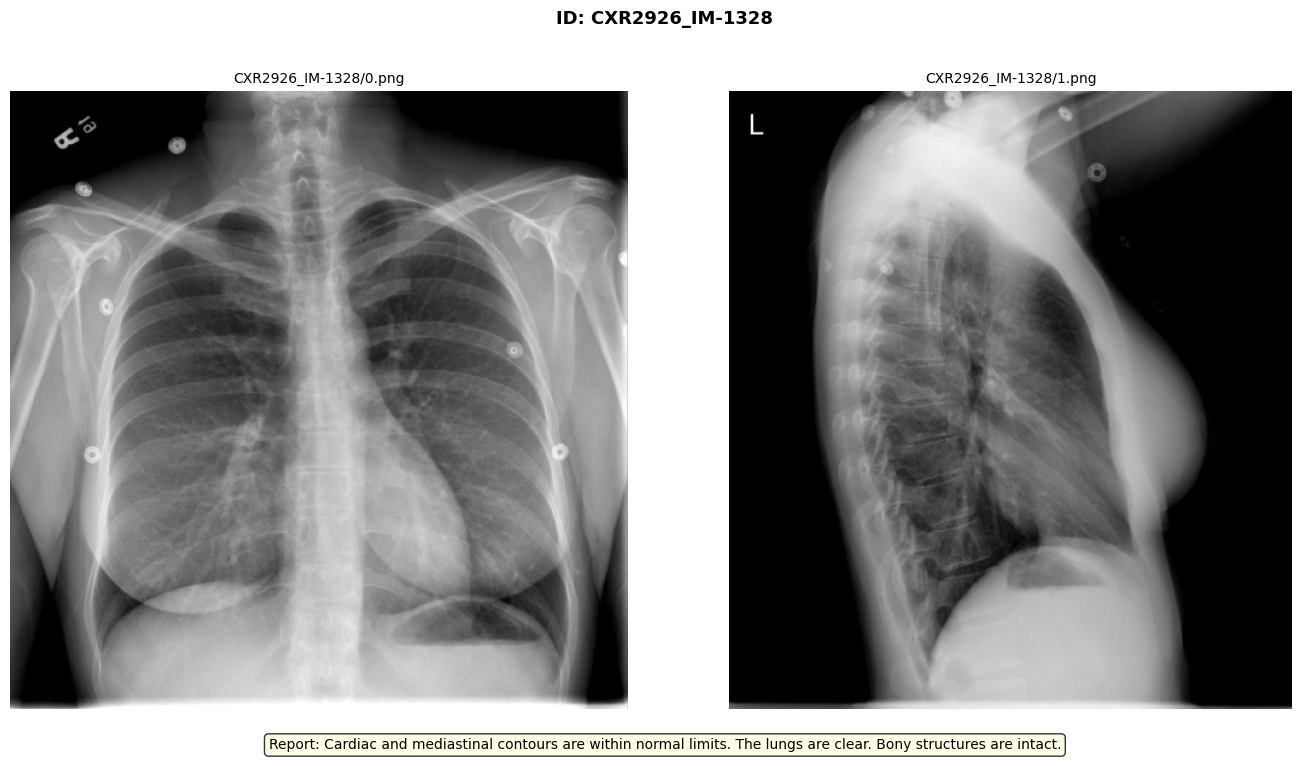

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Ví dụ về một annotation kèm theo hình ảnh
example_ann = train_anns[1]
print("Example annotation keys:", example_ann.keys())
print("Report:", example_ann['report'])
print("Image paths:", example_ann['image_path'])

# Vẽ hình ảnh kèm report
image_paths = example_ann['image_path']  # list các ảnh (thường là 2: frontal + lateral)
n_imgs = len(image_paths)

fig, axes = plt.subplots(1, n_imgs, figsize=(7 * n_imgs, 7))
if n_imgs == 1:
    axes = [axes]

for ax, img_rel_path in zip(axes, image_paths):
    full_path = os.path.join(IMAGE_DIR, img_rel_path)
    img = mpimg.imread(full_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(img_rel_path, fontsize=10)
    ax.axis('off')

# Thêm report làm caption phía dưới
fig.text(
    0.5, -0.02,
    f"Report: {example_ann['report']}",
    ha='center', va='top',
    fontsize=10, wrap=True,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
    transform=fig.transFigure
)

plt.suptitle(f"ID: {example_ann['id']}", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


- Mỗi sample bao gồm 2 ảnh x-ray (được chụp từ chính diện và bên hông) và 1 report về tình trạng của image

# Phân bổ độ dài báo cáo X-quang trong tập huấn luyện


  THỐNG KÊ ĐỘ DÀI REPORT (theo số từ)
count    2069.00
mean       31.77
std        14.21
min         7.00
25%        22.00
50%        29.00
75%        39.00
max       149.00

Mode  : 30 từ
Median: 29.0 từ


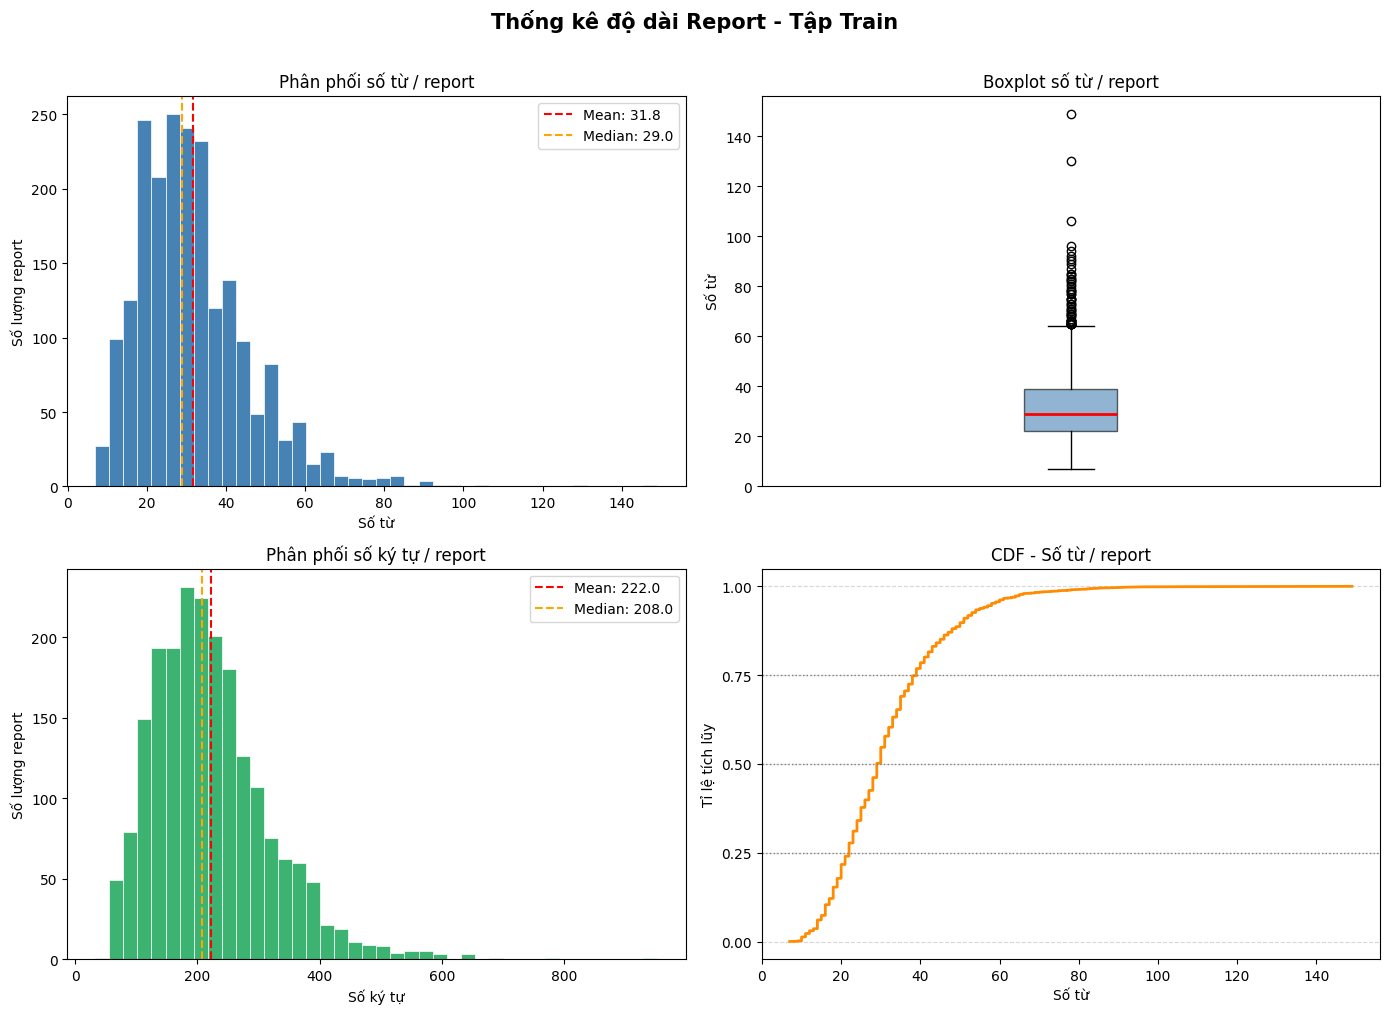

In [19]:
# Tính độ dài report (theo từ và ký tự)
train_df['report_word_count']  = train_df['report'].apply(lambda x: len(x.split()))
train_df['report_char_count']  = train_df['report'].apply(len)

# Thống kê mô tả
print("="*50)
print("  THỐNG KÊ ĐỘ DÀI REPORT (theo số từ)")
print("="*50)
print(train_df['report_word_count'].describe().round(2).to_string())
print(f"\nMode  : {train_df['report_word_count'].mode()[0]} từ")
print(f"Median: {train_df['report_word_count'].median():.1f} từ")
print("="*50)

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Thống kê độ dài Report - Tập Train", fontsize=15, fontweight='bold', y=1.01)

word_counts = train_df['report_word_count']
char_counts = train_df['report_char_count']

# 1. Histogram số từ
axes[0, 0].hist(word_counts, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0, 0].axvline(word_counts.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {word_counts.mean():.1f}')
axes[0, 0].axvline(word_counts.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {word_counts.median():.1f}')
axes[0, 0].set_title("Phân phối số từ / report")
axes[0, 0].set_xlabel("Số từ")
axes[0, 0].set_ylabel("Số lượng report")
axes[0, 0].legend()

# 2. Boxplot số từ
axes[0, 1].boxplot(word_counts, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6),
                   medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_title("Boxplot số từ / report")
axes[0, 1].set_ylabel("Số từ")
axes[0, 1].set_xticks([])

# 3. Histogram số ký tự
axes[1, 0].hist(char_counts, bins=40, color='mediumseagreen', edgecolor='white', linewidth=0.5)
axes[1, 0].axvline(char_counts.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {char_counts.mean():.1f}')
axes[1, 0].axvline(char_counts.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {char_counts.median():.1f}')
axes[1, 0].set_title("Phân phối số ký tự / report")
axes[1, 0].set_xlabel("Số ký tự")
axes[1, 0].set_ylabel("Số lượng report")
axes[1, 0].legend()

# 4. CDF (Cumulative Distribution)
sorted_words = np.sort(word_counts)
cdf = np.arange(1, len(sorted_words) + 1) / len(sorted_words)
axes[1, 1].plot(sorted_words, cdf, color='darkorange', linewidth=2)
axes[1, 1].axhline(0.25, color='gray',  linestyle=':', linewidth=1)
axes[1, 1].axhline(0.50, color='gray',  linestyle=':', linewidth=1)
axes[1, 1].axhline(0.75, color='gray',  linestyle=':', linewidth=1)
axes[1, 1].set_title("CDF - Số từ / report")
axes[1, 1].set_xlabel("Số từ")
axes[1, 1].set_ylabel("Tỉ lệ tích lũy")
axes[1, 1].set_yticks([0, 0.25, 0.5, 0.75, 1.0])
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Các mốc phần trăm cần thống kê
percentiles = [10, 20, 25, 30, 40, 50, 60, 70, 75, 80, 90, 95, 99, 100]

# Tính theo số từ và số ký tự
word_counts = train_df['report_word_count']
char_counts = train_df['report_char_count']

rows = []
for p in percentiles:
    w = np.percentile(word_counts, p)
    c = np.percentile(char_counts, p)
    rows.append({
        'Phần trăm (%)': f'{p}%',
        'Số từ (words)': int(w),
        'Số ký tự (chars)': int(c),
        'Số report ≤ mức này': int(len(word_counts) * p / 100),
    })

percentile_df = pd.DataFrame(rows)

# Hiển thị bảng đẹp
print("\n" + "="*65)
print("   PHÂN PHỐI ĐỘ DÀI REPORT THEO MỐC PHẦN TRĂM - Tập Train")
print("="*65)
print(percentile_df.to_string(index=False))
print("="*65)
print(f"  Tổng số report: {len(word_counts)}")
print(f"  Mean  : {word_counts.mean():.1f} từ  |  {char_counts.mean():.1f} ký tự")
print(f"  Std   : {word_counts.std():.1f} từ   |  {char_counts.std():.1f} ký tự")
print("="*65)


   PHÂN PHỐI ĐỘ DÀI REPORT THEO MỐC PHẦN TRĂM - Tập Train
Phần trăm (%)  Số từ (words)  Số ký tự (chars)  Số report ≤ mức này
 10%           16            115                206                
 20%           20            140                413                
 25%           22            154                517                
 30%           23            165                620                
 40%           27            186                827                
 50%           29            208               1034                
 60%           32            230               1241                
 70%           36            254               1448                
 75%           39            272               1551                
 80%           41            291               1655                
 90%           51            351               1862                
 95%           58            392               1965                
 99%           78            528               2048      

# Thống kê các report trùng lặp


   DUPLICATE REPORT DETECTION - Tập Train
  Tổng report       :   2069
  Report duy nhất   :   1728  (83.5%)
  Report bị lặp     :    341  (16.5%)
  Report phổ biến #1: 'The heart is normal in size. The mediastinum is unremarkable...'
                      → xuất hiện 29 lần (1.4%)
  Top 673 report duy nhất chiếm 50% toàn bộ tập train

  TOP 20 REPORT PHỔ BIẾN NHẤT
----------------------------------------------------------------------
   report_preview                                               frequency  percent (%)  cumulative (%)
1   The heart is normal in size. The mediastinum is unremar...  29         1.40          1.40         
2   Heart size normal. Lungs are clear. XXXX are normal. No...  25         1.21          2.61         
3   The heart and lungs have XXXX XXXX in the interval. Bot...  22         1.06          3.67         
4   The lungs are clear bilaterally. Specifically, no evide...  18         0.87          4.54         
5   Cardiac and mediastinal contours are with

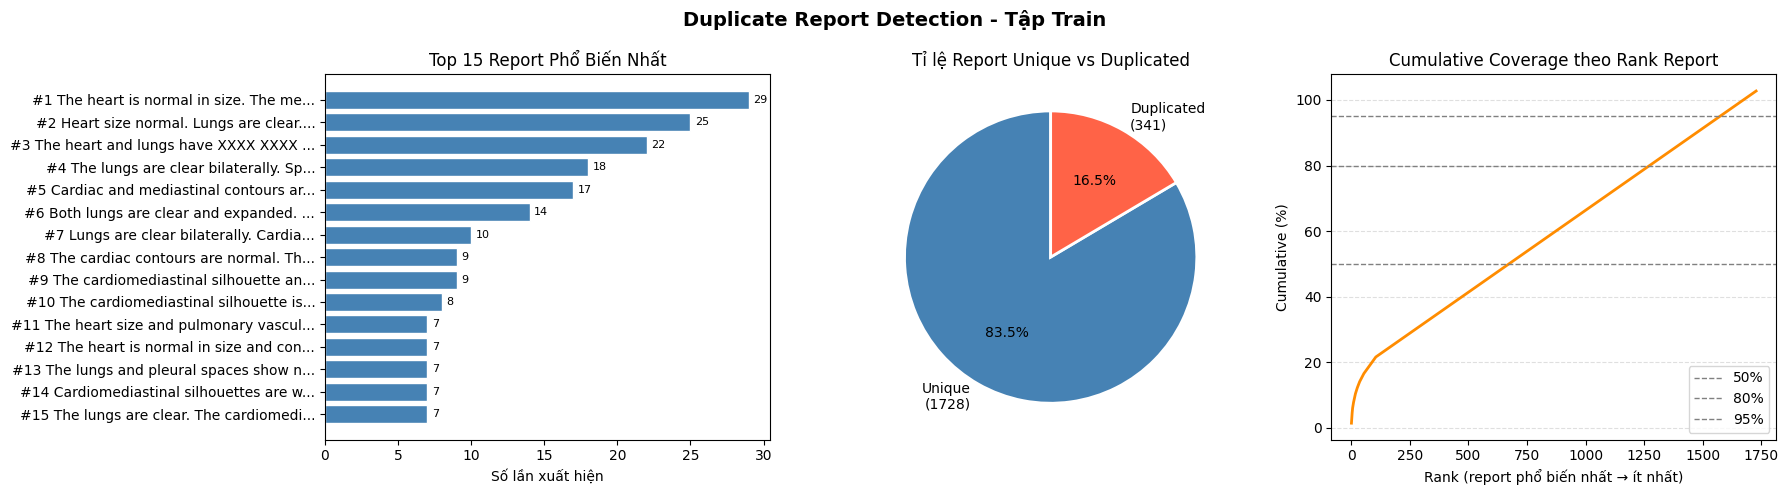

In [ ]:
# ── 1. Tần suất từng report ──────────────────────────────────────────
report_counts = Counter(train_df['report'].str.strip())
report_freq_df = pd.DataFrame(report_counts.most_common(), columns=['report', 'frequency'])
report_freq_df['percent (%)'] = (report_freq_df['frequency'] / len(train_df) * 100).round(2)
report_freq_df['cumulative (%)'] = report_freq_df['percent (%)'].cumsum().round(2)
report_freq_df.index += 1  # rank bắt đầu từ 1

# ── 2. Thống kê tổng quan ────────────────────────────────────────────
n_total        = len(train_df)
n_unique       = len(report_freq_df)
n_duplicated   = n_total - n_unique
top1_report    = report_freq_df.iloc[0]
top1_cover     = report_freq_df[report_freq_df['cumulative (%)'] <= 50].shape[0]

print("\n" + "="*70)
print("   DUPLICATE REPORT DETECTION - Tập Train")
print("="*70)
print(f"  Tổng report       : {n_total:>6}")
print(f"  Report duy nhất   : {n_unique:>6}  ({n_unique/n_total*100:.1f}%)")
print(f"  Report bị lặp     : {n_duplicated:>6}  ({n_duplicated/n_total*100:.1f}%)")
print(f"  Report phổ biến #1: '{top1_report['report'][:60]}...'")
print(f"                      → xuất hiện {top1_report['frequency']} lần ({top1_report['percent (%)']:.1f}%)")
print(f"  Top {top1_cover} report duy nhất chiếm 50% toàn bộ tập train")
print("="*70)

# ── 3. Bảng Top 20 report phổ biến nhất ─────────────────────────────
print("\n  TOP 20 REPORT PHỔ BIẾN NHẤT")
print("-"*70)
display_top = report_freq_df.head(20).copy()
display_top['report_preview'] = display_top['report'].str[:55] + '...'
print(display_top[['report_preview', 'frequency', 'percent (%)', 'cumulative (%)']].to_string())
print("-"*70)

# ── 4. Phân nhóm theo tần suất ──────────────────────────────────────
bins   = [1, 2, 5, 10, 50, float('inf')]
labels = ['1 lần (unique)', '2–4 lần', '5–9 lần', '10–49 lần', '≥50 lần']
report_freq_df['freq_group'] = pd.cut(report_freq_df['frequency'], bins=bins, labels=labels, right=False)
group_stats = (
    report_freq_df.groupby('freq_group', observed=True)
    .agg(
        số_report_unique=('frequency', 'count'),
        tổng_xuất_hiện=('frequency', 'sum')
    )
    .assign(**{'chiếm (%)': lambda d: (d['tổng_xuất_hiện'] / n_total * 100).round(2)})
)

print("\n  PHÂN NHÓM THEO TẦN SUẤT")
print("-"*55)
print(group_stats.to_string())
print("-"*55)

# ── 5. Biểu đồ ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Duplicate Report Detection - Tập Train", fontsize=14, fontweight='bold')

# 5a. Bar chart Top 15
top15 = report_freq_df.head(15)
bars = axes[0].barh(
    [f"#{i} {r[:35]}..." for i, r in zip(top15.index, top15['report'])],
    top15['frequency'],
    color='steelblue', edgecolor='white'
)
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Report Phổ Biến Nhất")
axes[0].set_xlabel("Số lần xuất hiện")
for bar, val in zip(bars, top15['frequency']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=8)

# 5b. Pie chart: unique vs duplicated
axes[1].pie(
    [n_unique, n_duplicated],
    labels=[f'Unique\n({n_unique})', f'Duplicated\n({n_duplicated})'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title("Tỉ lệ Report Unique vs Duplicated")

# 5c. Cumulative coverage
axes[2].plot(report_freq_df.index, report_freq_df['cumulative (%)'],
             color='darkorange', linewidth=2)
for threshold in [50, 80, 95]:
    axes[2].axhline(threshold, linestyle='--', linewidth=1, color='gray',
                    label=f'{threshold}%')
axes[2].set_title("Cumulative Coverage theo Rank Report")
axes[2].set_xlabel("Rank (report phổ biến nhất → ít nhất)")
axes[2].set_ylabel("Cumulative (%)")
axes[2].legend()
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Sentence embedding clustering

Loading SentenceTransformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 1728 unique reports...


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Embedding shape: (2069, 384)

Finding optimal K...


100%|██████████| 14/14 [00:11<00:00,  1.25it/s]



→ Optimal K by Silhouette: 15

   CLUSTER SUMMARY  (K=15)
    Cluster  Số report  Tỉ lệ (%) Report đại diện                                                                     
1    1       275        13.29      The cardiomediastinal silhouette is normal in size and contour. Lungs are clear ...
2   11       239        11.55      Lungs are clear. There is no pleural effusion or pneumothorax. The heart and med...
3    9       207        10.00      The heart is normal in size. The pulmonary vascularity is within normal limits i...
4    5       200         9.67      The cardiac and mediastinal contours are within normal limits. Lungs are well-in...
5    3       181         8.75      The lungs are hyperexpanded. There is a large rounded lucency in the right upper...
6    0       168         8.12      Normal heart size and mediastinal contours. The lungs are clear. There is no pne...
7    7       156         7.54      Cardiomegaly is present. The pulmonary vascularity appears within normal 

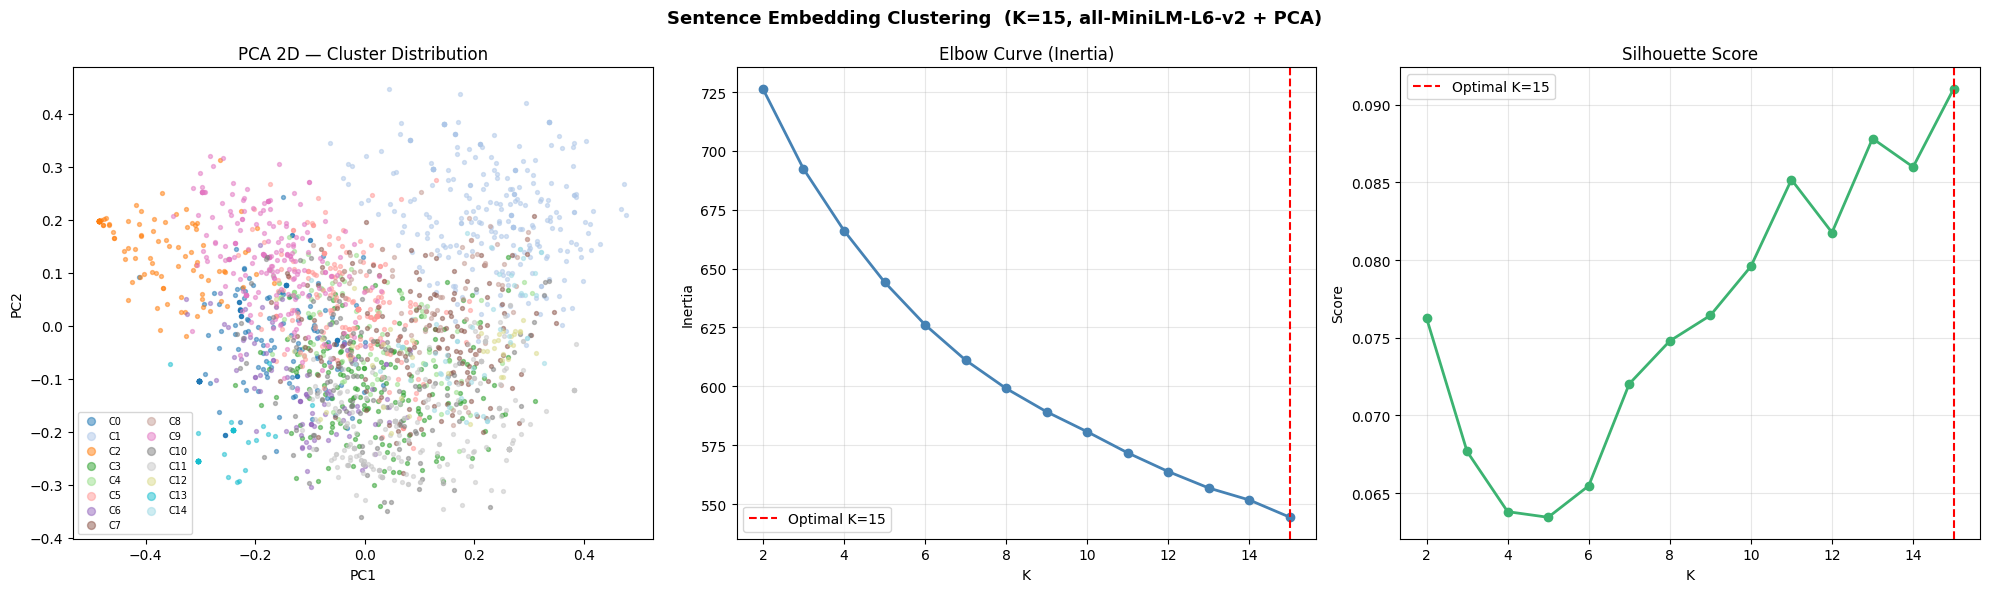

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ── 1. Embed reports ─────────────────────────────────────────────────
print("Loading SentenceTransformer model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')  # nhẹ, nhanh, tốt cho medical text

unique_reports = train_df['report'].str.strip().unique()
print(f"Embedding {len(unique_reports)} unique reports...")

embeddings_unique = embedder.encode(
    unique_reports,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

# Map embedding về toàn bộ train_df
report_to_idx = {r: i for i, r in enumerate(unique_reports)}
embeddings_all = np.array([
    embeddings_unique[report_to_idx[r.strip()]]
    for r in train_df['report']
])
print(f"Embedding shape: {embeddings_all.shape}")

# ── 2. Chọn số cluster tối ưu (Elbow + Silhouette) ───────────────────
K_range = range(2, 16)
inertias, silhouettes = [], []

print("\nFinding optimal K...")
for k in tqdm(K_range):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings_all)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(embeddings_all, labels, sample_size=1000, random_state=42))

# ── 3. Fit KMeans với K tối ưu ───────────────────────────────────────
OPTIMAL_K = K_range.start + int(np.argmax(silhouettes))
print(f"\n→ Optimal K by Silhouette: {OPTIMAL_K}")

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_all)
train_df['cluster'] = cluster_labels

# ── 4. Tìm report đại diện cho mỗi cluster ──────────────────────────
print("\n" + "="*70)
print(f"   CLUSTER SUMMARY  (K={OPTIMAL_K})")
print("="*70)

cluster_summary = []
for c in range(OPTIMAL_K):
    mask        = cluster_labels == c
    cluster_emb = embeddings_all[mask]
    center      = kmeans.cluster_centers_[c]
    dists       = np.linalg.norm(cluster_emb - center, axis=1)
    closest_idx = np.where(mask)[0][np.argmin(dists)]
    rep_report  = train_df['report'].iloc[closest_idx]

    cluster_summary.append({
        'Cluster': c,
        'Số report': mask.sum(),
        'Tỉ lệ (%)': round(mask.sum() / len(train_df) * 100, 2),
        'Report đại diện': rep_report[:80] + ('...' if len(rep_report) > 80 else '')
    })

summary_df = pd.DataFrame(cluster_summary).sort_values('Số report', ascending=False)
summary_df.index = range(1, len(summary_df) + 1)
print(summary_df.to_string(index=True))
print("="*70)

# ── 5. Top 3 report phổ biến nhất trong mỗi cluster ─────────────────
print("\n  TOP 3 REPORTS PHỔ BIẾN NHẤT TRONG MỖI CLUSTER")
print("-"*70)
for c in summary_df['Cluster']:
    sub = train_df[train_df['cluster'] == c]['report'].value_counts().head(3)
    print(f"\n  【Cluster {c}】 ({(cluster_labels==c).sum()} reports)")
    for rank, (report, cnt) in enumerate(sub.items(), 1):
        print(f"    #{rank} ({cnt}x) {report[:70]}{'...' if len(report)>70 else ''}")
print("-"*70)

# ── 6. Visualisation ─────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings_all)
colors = cm.tab20(np.linspace(0, 1, OPTIMAL_K))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"Sentence Embedding Clustering  (K={OPTIMAL_K}, all-MiniLM-L6-v2 + PCA)",
             fontsize=13, fontweight='bold')

# 6a. Scatter PCA
for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    color=colors[c], s=8, alpha=0.5, label=f'C{c}')
axes[0].set_title("PCA 2D — Cluster Distribution")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(markerscale=2, fontsize=7, ncol=2)

# 6b. Elbow curve
axes[1].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[1].set_title("Elbow Curve (Inertia)")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Inertia")
axes[1].axvline(OPTIMAL_K, color='red', linestyle='--', label=f'Optimal K={OPTIMAL_K}')
axes[1].legend(); axes[1].grid(alpha=0.3)

# 6c. Silhouette score
axes[2].plot(list(K_range), silhouettes, 'o-', color='mediumseagreen', linewidth=2)
axes[2].set_title("Silhouette Score")
axes[2].set_xlabel("K"); axes[2].set_ylabel("Score")
axes[2].axvline(OPTIMAL_K, color='red', linestyle='--', label=f'Optimal K={OPTIMAL_K}')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Nhận xét:**
- *Shilhouette Score* thấp (~ 0.065 -> 0.09) -> không có tách biệt rõ ràng trong không gian Embedding -> Phản ánh bản chất của Radiology Report: ngôn ngữ y khoa khá đồng nhất, ranh giới giữa "normal" và "mild abnormality" rất mờ nhạt về mặt ngữ nghĩa.
-

# Visualize using UMAP

Fitting UMAP...
start.....


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


end.....


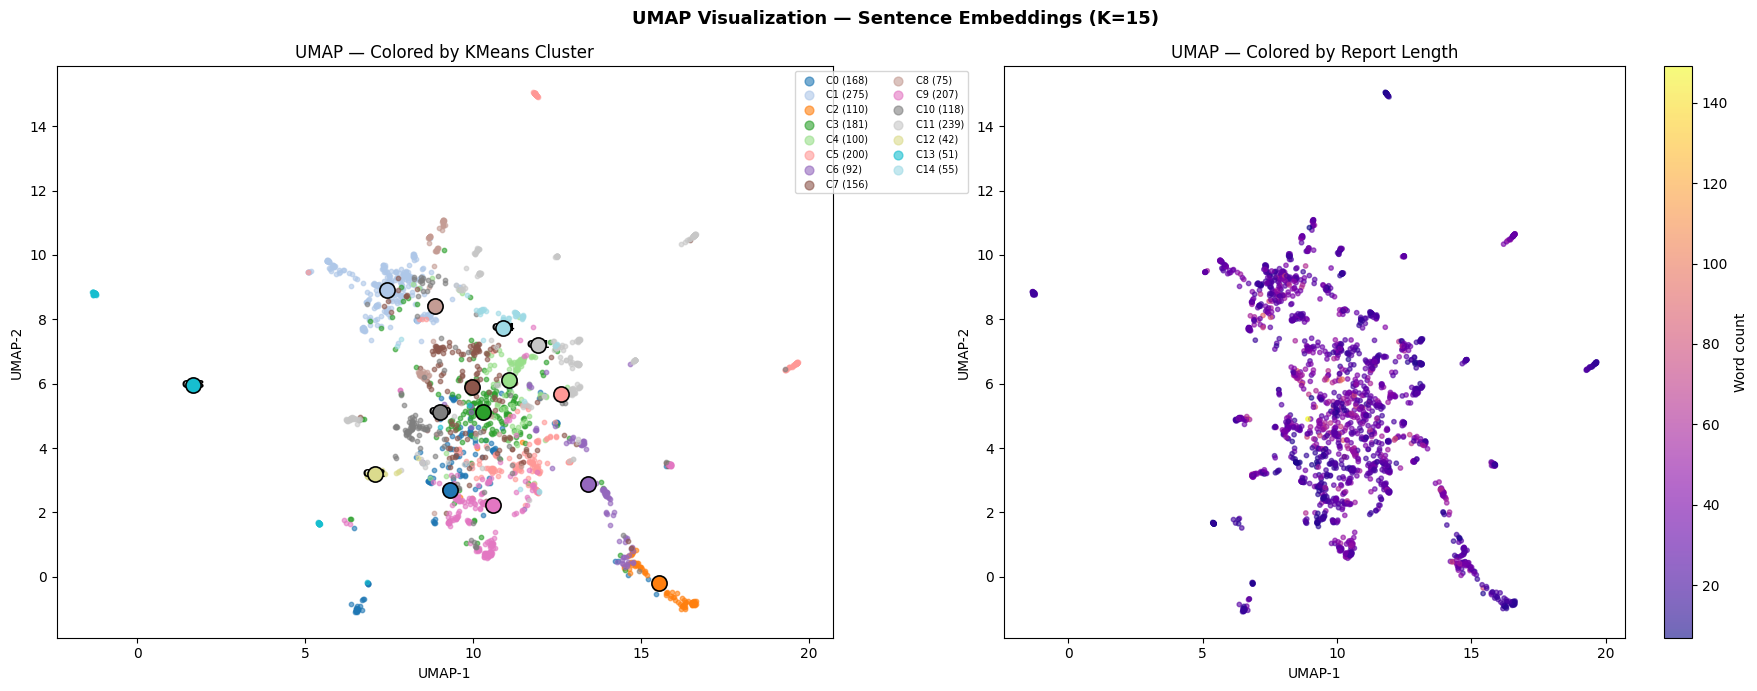

In [23]:
import umap

# ── 1. Fit UMAP ──────────────────────────────────────────────────────
print("Fitting UMAP...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,       # láng giềng càng lớn → cấu trúc global càng rõ
    min_dist=0.1,         # điểm càng gần nhau trong cluster
    metric='cosine',      # phù hợp với sentence embeddings (đã normalize)
    random_state=42
)
print("start.....")
coords_umap = reducer.fit_transform(embeddings_all)
print("end.....")

# ── 2. Visualize ─────────────────────────────────────────────────────
colors = cm.tab20(np.linspace(0, 1, OPTIMAL_K))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f"UMAP Visualization — Sentence Embeddings (K={OPTIMAL_K})",
             fontsize=13, fontweight='bold')

# 2a. Tô màu theo cluster
for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    axes[0].scatter(
        coords_umap[mask, 0], coords_umap[mask, 1],
        color=colors[c], s=10, alpha=0.6, label=f'C{c} ({mask.sum()})'
    )
    # Vẽ tâm cluster
    cx, cy = coords_umap[mask, 0].mean(), coords_umap[mask, 1].mean()
    axes[0].scatter(cx, cy, color=colors[c], s=120, edgecolors='black', linewidths=1.2, zorder=5)
    axes[0].annotate(f'C{c}', (cx, cy), fontsize=8, fontweight='bold',
                     ha='center', va='center', color='black')

axes[0].set_title("UMAP — Colored by KMeans Cluster")
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
axes[0].legend(markerscale=2, fontsize=7, ncol=2,
               loc='upper right', bbox_to_anchor=(1.18, 1))

# 2b. Tô màu theo độ dài report (word count) → thấy correlation
sc = axes[1].scatter(
    coords_umap[:, 0], coords_umap[:, 1],
    c=train_df['report_word_count'],
    cmap='plasma', s=10, alpha=0.6
)
plt.colorbar(sc, ax=axes[1], label='Word count')
axes[1].set_title("UMAP — Colored by Report Length")
axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")

plt.tight_layout()
plt.show()

# Medical Entity Analysis

Running CheXpert labeler...


100%|██████████| 2069/2069 [00:00<00:00, 9447.62it/s] 



Loading BioClinicalBERT NER model...


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

...

100%|██████████| 2069/2069 [16:08<00:00,  2.14it/s]


  → disease_counter empty, using direct keyword fallback...
  disease entities found : 15
  anatomy entities found : 11
  severity entities found: 45
Extracting RadGraph triplets...


100%|██████████| 2069/2069 [00:00<00:00, 31777.47it/s]



  CHEXPERT LABEL FREQUENCY
Condition                   Positive  Prevalence(%)
                No Finding 1678      81.10         
               Lung Lesion  316      15.27         
          Pleural Effusion  298      14.40         
              Pneumothorax  252      12.18         
              Lung Opacity  150       7.25         
             Consolidation  150       7.25         
               Atelectasis  144       6.96         
           Support Devices  122       5.90         
              Cardiomegaly   90       4.35         
                  Fracture   61       2.95         
                     Edema   43       2.08         
                 Pneumonia   25       1.21         
             Pleural Other   15       0.72         
Enlarged Cardiomediastinum    0       0.00         

  TOP 20 DISEASE ENTITIES (NER)
----------------------------------------
   1. effusion                   1596  ██████████████████████████████
   2. pneumothorax               1448  █████████

/tmp/ipykernel_518/1566200056.py:317: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


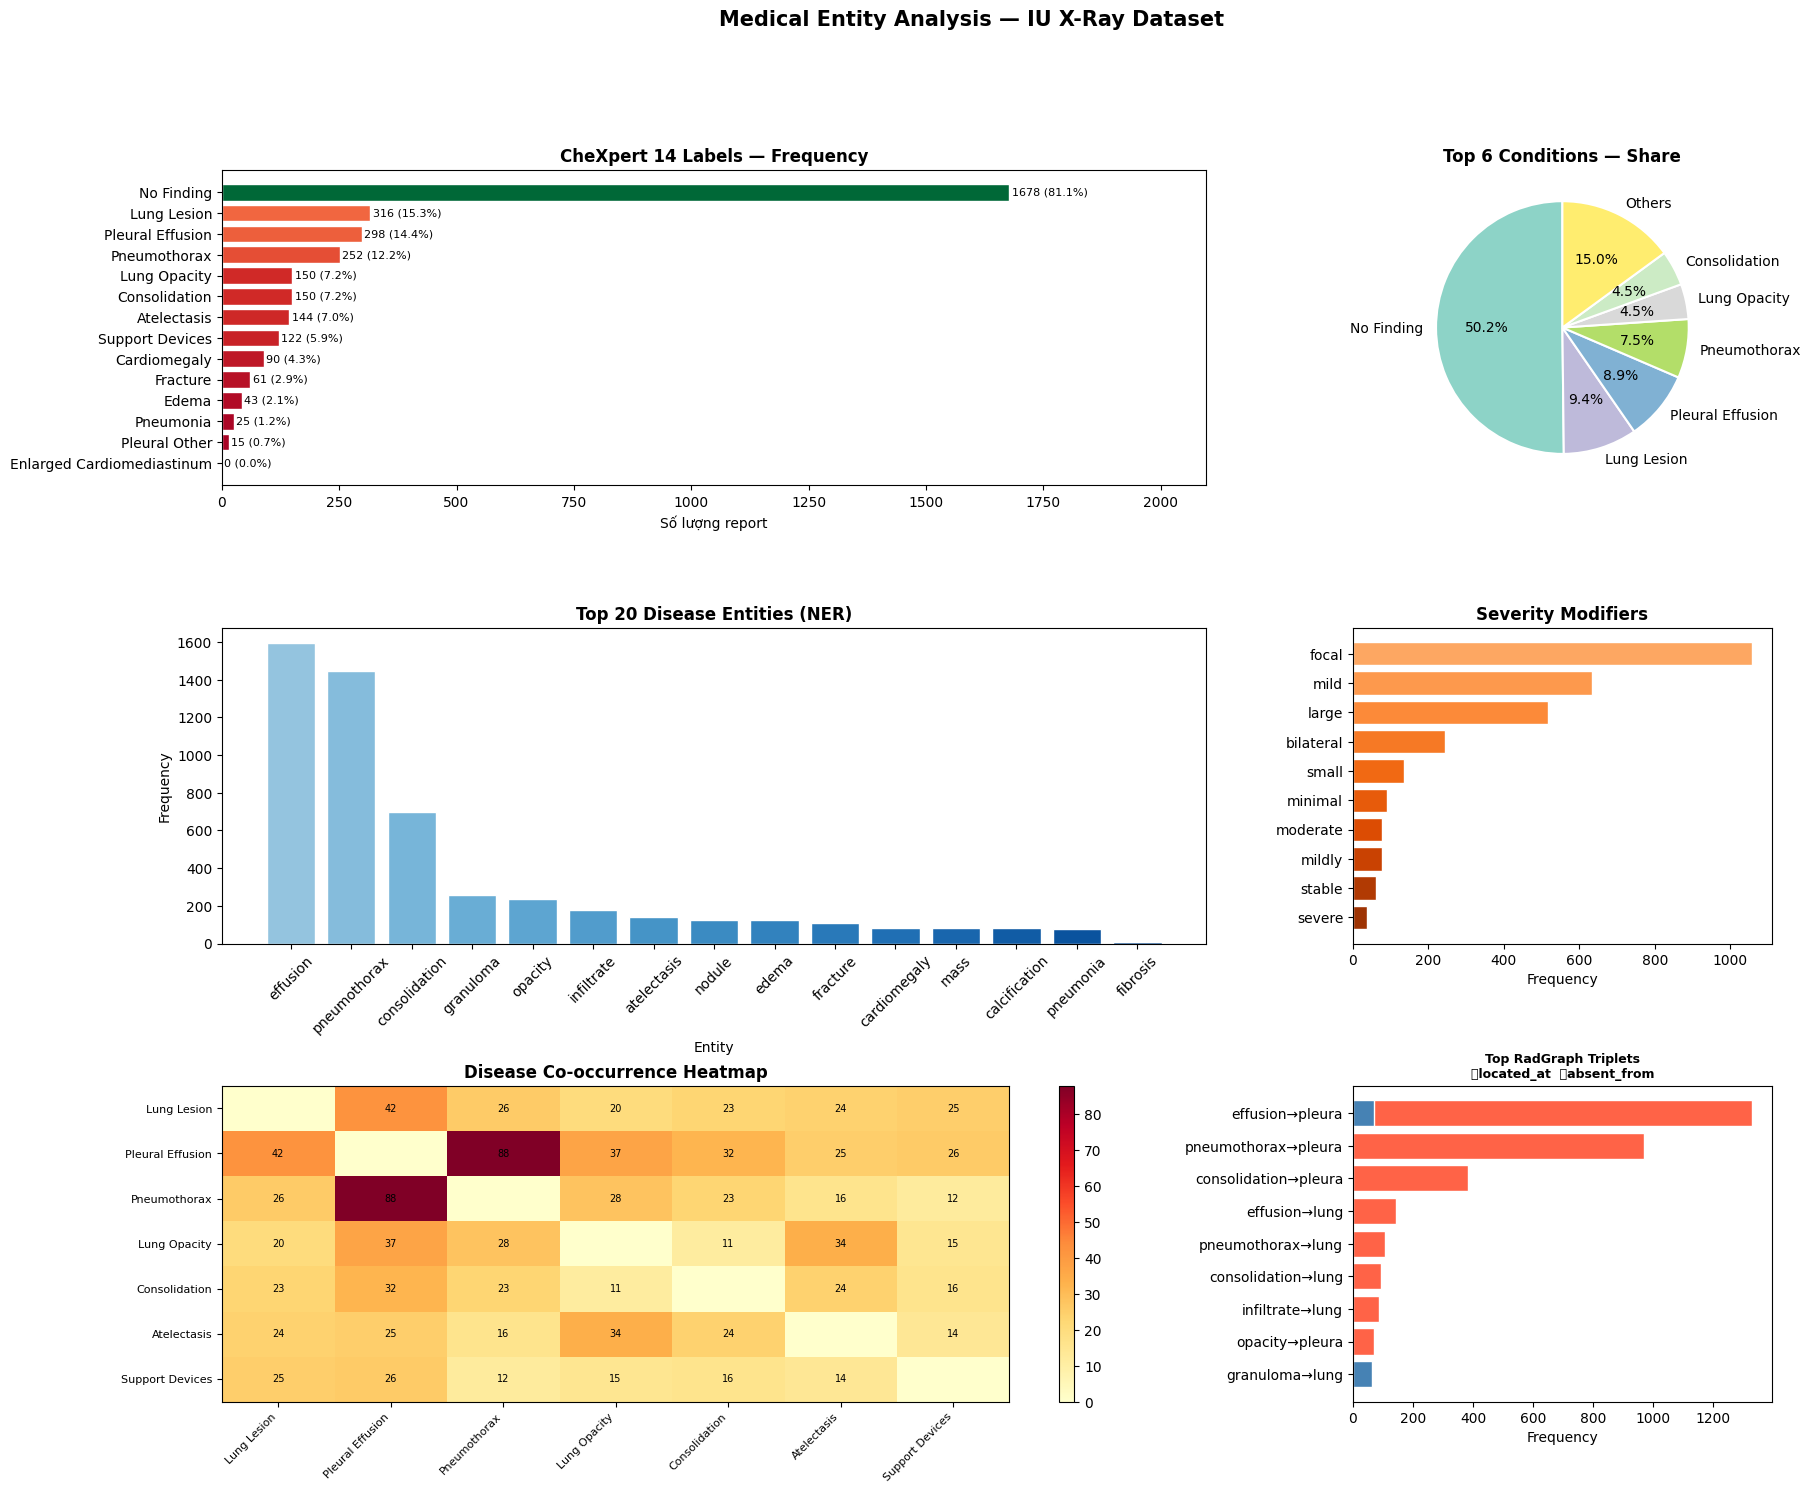

In [ ]:
# ════════════════════════════════════════════════════════════════════
#  MEDICAL ENTITY ANALYSIS
#  3 approaches: CheXpert labeler · RadGraph · BioClinicalBERT NER
# ════════════════════════════════════════════════════════════════════

import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from tqdm import tqdm

# ─────────────────────────────────────────────────────────────────────
# METHOD 1 · CheXpert Labeler (rule-based, fastest)
# ─────────────────────────────────────────────────────────────────────
# CheXpert định nghĩa 14 nhãn chuẩn trong radiology
CHEXPERT_CONDITIONS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
    'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
    'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
    'Pleural Other', 'Fracture', 'Support Devices'
]

# Keyword mapping cho từng condition (simplified CheXpert rule)
CHEXPERT_KEYWORDS = {
    'No Finding'                  : ['no acute', 'normal', 'unremarkable', 'no abnormality', 'clear'],
    'Enlarged Cardiomediastinum'  : ['enlarged mediastinum', 'widened mediastinum', 'mediastinal widening'],
    'Cardiomegaly'                : ['cardiomegaly', 'cardiac enlargement', 'enlarged heart', 'cardiac silhouette is enlarged'],
    'Lung Opacity'                : ['opacity', 'opacification', 'haziness', 'infiltrate'],
    'Lung Lesion'                 : ['nodule', 'mass', 'lesion', 'granuloma'],
    'Edema'                       : ['edema', 'pulmonary vascular congestion', 'vascular engorgement'],
    'Consolidation'               : ['consolidation', 'airspace disease'],
    'Pneumonia'                   : ['pneumonia', 'infection'],
    'Atelectasis'                 : ['atelectasis', 'atelectatic', 'collapse'],
    'Pneumothorax'                : ['pneumothorax'],
    'Pleural Effusion'            : ['pleural effusion', 'effusion', 'pleural fluid'],
    'Pleural Other'               : ['pleural thickening', 'pleural scarring', 'pleural disease'],
    'Fracture'                    : ['fracture', 'rib fracture', 'compression fracture'],
    'Support Devices'             : ['pacemaker', 'catheter', 'tube', 'device', 'wire', 'stent'],
}

NEGATION_TERMS = ['no ', 'without ', 'absent', 'negative', 'not ', 'none', 'free of']

def chexpert_label(report: str) -> dict:
    """Simplified CheXpert labeling: 1=positive, 0=negative, -1=uncertain"""
    report_lower = report.lower()
    labels = {}
    for condition, keywords in CHEXPERT_KEYWORDS.items():
        found = any(kw in report_lower for kw in keywords)
        if not found:
            labels[condition] = 0
            continue
        # Kiểm tra negation trong cửa sổ 40 ký tự trước keyword
        negated = False
        for kw in keywords:
            idx = report_lower.find(kw)
            if idx != -1:
                window = report_lower[max(0, idx-40):idx]
                if any(neg in window for neg in NEGATION_TERMS):
                    negated = True
        labels[condition] = 0 if negated else 1
    return labels

print("Running CheXpert labeler...")
chexpert_results = [chexpert_label(r) for r in tqdm(train_df['report'])]
chexpert_df = pd.DataFrame(chexpert_results)
train_df = pd.concat([train_df.reset_index(drop=True), chexpert_df], axis=1)

# ─────────────────────────────────────────────────────────────────────
# METHOD 2 · BioClinicalBERT NER  (deep learning)
# ─────────────────────────────────────────────────────────────────────
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification

print("\nLoading BioClinicalBERT NER model...")
ner_pipeline = pipeline(
    "ner",
    model="allenai/scibert_scivocab_uncased",   # fallback nếu không có GPU
    # model="uer/roberta-base-finetuned-jd-full-chinese" # thay bằng medical NER model nếu có
    aggregation_strategy="simple",
    device=-1   # CPU; đổi thành 0 nếu có GPU
)

# Dùng model chuyên medical NER hơn nếu available
try:
    ner_pipeline = pipeline(
        "ner",
        model="blaze999/Medical-NER",
        aggregation_strategy="simple",
        device=-1
    )
    print("  → Using Medical-NER model")
except Exception:
    print("  → Fallback: using keyword-based NER")
    ner_pipeline = None

# Medical entity keywords fallback
MEDICAL_ENTITIES = {
    'DISEASE'   : ['pneumonia','effusion','atelectasis','cardiomegaly','edema',
                   'consolidation','pneumothorax','nodule','mass','granuloma',
                   'fracture','opacity','infiltrate','fibrosis','calcification'],
    'ANATOMY'   : ['lung','heart','mediastinum','pleura','rib','diaphragm',
                   'trachea','hilum','aorta','spine','clavicle'],
    'SEVERITY'  : ['mild','moderate','severe','minimal','marked','bilateral',
                   'unilateral','diffuse','focal','small','large'],
}

def keyword_ner(report: str) -> list[dict]:
    report_lower = report.lower()
    entities = []
    for ent_type, keywords in MEDICAL_ENTITIES.items():
        for kw in keywords:
            if kw in report_lower:
                entities.append({'entity_group': ent_type, 'word': kw})
    return entities

print("Running NER on reports...")
all_entities = []
for report in tqdm(train_df['report']):
    if ner_pipeline:
        try:
            ents = ner_pipeline(report[:512])  # BERT max token limit
        except Exception:
            ents = keyword_ner(report)
    else:
        ents = keyword_ner(report)
    all_entities.append(ents)

# Tổng hợp entity frequency
entity_counter   = Counter()
disease_counter  = Counter()
anatomy_counter  = Counter()
severity_counter = Counter()

for ents in all_entities:
    for e in ents:
        word  = e['word'].lower().strip()
        group = e.get('entity_group', 'MISC').upper()
        entity_counter[word] += 1
        if group in ('DISEASE', 'PROBLEM', 'CONDITION', 'DISORDER'):
            disease_counter[word] += 1
        elif group in ('ANATOMY', 'BODY_PART', 'ORGAN'):
            anatomy_counter[word] += 1
        elif group in ('SEVERITY', 'MODIFIER'):
            severity_counter[word] += 1
if len(disease_counter) == 0:
    print("  → disease_counter empty, using direct keyword fallback...")
    for report in train_df['report']:
        report_lower = report.lower()
        for kw in MEDICAL_ENTITIES['DISEASE']:
            if kw in report_lower:
                disease_counter[kw] += 1
        for kw in MEDICAL_ENTITIES['ANATOMY']:
            if kw in report_lower:
                anatomy_counter[kw] += 1
        for kw in MEDICAL_ENTITIES['SEVERITY']:
            if kw in report_lower:
                severity_counter[kw] += 1

print(f"  disease entities found : {len(disease_counter)}")
print(f"  anatomy entities found : {len(anatomy_counter)}")
print(f"  severity entities found: {len(severity_counter)}")
# ─────────────────────────────────────────────────────────────────────
# METHOD 3 · RadGraph-style relation extraction (keyword proximity)
# ─────────────────────────────────────────────────────────────────────
# RadGraph trích xuất (entity, relation, entity) triplets
# Ví dụ: (cardiomegaly) --located_at--> (heart)
def extract_radgraph_triplets(report: str) -> list[tuple]:
    triplets = []
    report_lower = report.lower()
    for disease in MEDICAL_ENTITIES['DISEASE']:
        if disease not in report_lower:
            continue
        for anatomy in MEDICAL_ENTITIES['ANATOMY']:
            # Kiểm tra 2 entity xuất hiện trong cùng 1 câu
            for sent in report_lower.split('.'):
                if disease in sent and anatomy in sent:
                    # Xác định relation
                    if any(neg in sent[:sent.find(disease)] for neg in NEGATION_TERMS):
                        relation = 'absent_from'
                    else:
                        relation = 'located_at'
                    triplets.append((disease, relation, anatomy))
    return triplets

print("Extracting RadGraph triplets...")
all_triplets = []
for report in tqdm(train_df['report']):
    all_triplets.extend(extract_radgraph_triplets(report))

triplet_counter = Counter(all_triplets)

# ─────────────────────────────────────────────────────────────────────
# SUMMARY TABLES
# ─────────────────────────────────────────────────────────────────────
# CheXpert label frequency
chexpert_freq = pd.DataFrame({
    'Condition'    : CHEXPERT_CONDITIONS,
    'Positive'     : [chexpert_df[c].sum() for c in CHEXPERT_CONDITIONS],
    'Prevalence(%)': [(chexpert_df[c].sum() / len(train_df) * 100).round(2)
                      for c in CHEXPERT_CONDITIONS]
}).sort_values('Positive', ascending=False)

print("\n" + "="*55)
print("  CHEXPERT LABEL FREQUENCY")
print("="*55)
print(chexpert_freq.to_string(index=False))
print("="*55)

# Top disease entities from NER
print("\n  TOP 20 DISEASE ENTITIES (NER)")
print("-"*40)
for i, (word, cnt) in enumerate(disease_counter.most_common(20), 1):
    bar = '█' * int(cnt / max(disease_counter.values()) * 30)
    print(f"  {i:>2}. {word:<25} {cnt:>5}  {bar}")
print("-"*40)

# Top RadGraph triplets
print("\n  TOP 15 RADGRAPH TRIPLETS")
print("-"*55)
for (d, r, a), cnt in triplet_counter.most_common(15):
    print(f"  ({d}) --{r}--> ({a})  ×{cnt}")
print("-"*55)

# ─────────────────────────────────────────────────────────────────────
# VISUALIZATION
# ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 16))
fig.suptitle("Medical Entity Analysis — IU X-Ray Dataset", fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

colors_main = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(CHEXPERT_CONDITIONS)))

# ── Plot 1: CheXpert label bar chart ──
ax1 = fig.add_subplot(gs[0, :2])
sorted_chex = chexpert_freq.sort_values('Positive', ascending=True)
bars = ax1.barh(sorted_chex['Condition'], sorted_chex['Positive'],
                color=plt.cm.RdYlGn(sorted_chex['Positive'] / sorted_chex['Positive'].max()),
                edgecolor='white')
for bar, val in zip(bars, sorted_chex['Positive']):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{val} ({val/len(train_df)*100:.1f}%)', va='center', fontsize=8)
ax1.set_title("CheXpert 14 Labels — Frequency", fontweight='bold')
ax1.set_xlabel("Số lượng report")
ax1.set_xlim(0, sorted_chex['Positive'].max() * 1.25)

# ── Plot 2: Prevalence pie ──
ax2 = fig.add_subplot(gs[0, 2])
top6 = chexpert_freq.head(6)
other_val = chexpert_freq['Positive'].iloc[6:].sum()
pie_vals   = list(top6['Positive']) + [other_val]
pie_labels = list(top6['Condition']) + ['Others']
ax2.pie(pie_vals, labels=pie_labels, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.Set3(np.linspace(0, 1, len(pie_vals))),
        wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax2.set_title("Top 6 Conditions — Share", fontweight='bold')

# Plot 3: NER disease entity bar
ax3 = fig.add_subplot(gs[1, :2])
if disease_counter:
    top_diseases = disease_counter.most_common(20)
    d_words, d_counts = zip(*top_diseases)
    bar_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(d_words)))
    ax3.bar(d_words, d_counts, color=bar_colors, edgecolor='white')
    ax3.set_xlabel("Entity"); ax3.set_ylabel("Frequency")
    ax3.tick_params(axis='x', rotation=45)
else:
    ax3.text(0.5, 0.5, 'No disease entities found', ha='center', va='center',
             transform=ax3.transAxes, fontsize=12, color='gray')
ax3.set_title("Top 20 Disease Entities (NER)", fontweight='bold')

# Plot 4: Severity
ax4 = fig.add_subplot(gs[1, 2])
if severity_counter:
    sev_words, sev_counts = zip(*severity_counter.most_common(10))
    ax4.barh(sev_words, sev_counts,
             color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(sev_words))),
             edgecolor='white')
    ax4.invert_yaxis()
    ax4.set_xlabel("Frequency")
else:
    ax4.text(0.5, 0.5, 'No severity entities found', ha='center', va='center',
             transform=ax4.transAxes, fontsize=12, color='gray')
ax4.set_title("Severity Modifiers", fontweight='bold')

# ── Plot 5: Co-occurrence heatmap (top 8 conditions) ──
ax5 = fig.add_subplot(gs[2, :2])
top8 = [c for c in chexpert_freq['Condition'].head(8) if c != 'No Finding'][:8]
cooc = np.zeros((len(top8), len(top8)), dtype=int)
for i, c1 in enumerate(top8):
    for j, c2 in enumerate(top8):
        cooc[i, j] = ((chexpert_df[c1] == 1) & (chexpert_df[c2] == 1)).sum()
np.fill_diagonal(cooc, 0)
im = ax5.imshow(cooc, cmap='YlOrRd', aspect='auto')
ax5.set_xticks(range(len(top8))); ax5.set_xticklabels(top8, rotation=45, ha='right', fontsize=8)
ax5.set_yticks(range(len(top8))); ax5.set_yticklabels(top8, fontsize=8)
for i in range(len(top8)):
    for j in range(len(top8)):
        if cooc[i, j] > 0:
            ax5.text(j, i, str(cooc[i, j]), ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax5)
ax5.set_title("Disease Co-occurrence Heatmap", fontweight='bold')

# ── Plot 6: RadGraph top triplets ──
ax6 = fig.add_subplot(gs[2, 2])
top_triplets = triplet_counter.most_common(10)
if top_triplets:
    t_labels = [f"{d}→{a}" for (d,r,a),_ in top_triplets]
    t_counts = [c for _,c in top_triplets]
    t_colors = ['tomato' if 'absent' in r else 'steelblue'
                for (d,r,a),_ in top_triplets]
    ax6.barh(t_labels, t_counts, color=t_colors, edgecolor='white')
    ax6.invert_yaxis()
    ax6.set_title("Top RadGraph Triplets\n🔵located_at  🔴absent_from", fontweight='bold', fontsize=9)
    ax6.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

# Image EDA

## 1 Image quality distribution

In [ ]:
import cv2
import matplotlib.gridspec as gridspec
from pathlib import Path
from skimage.measure import shannon_entropy
from PIL import Image
import torch
import torchvision.transforms as T
import torchvision.models as models
from sklearn.metrics.pairwise import cosine_similarity

# ════════════════════════════════════════════════════════════════════
# HELPER: Load ảnh an toàn
# ════════════════════════════════════════════════════════════════════
def safe_load_image(path: str):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        try:
            img = np.array(Image.open(path).convert('L'))
        except Exception:
            return None
    return img

# ════════════════════════════════════════════════════════════════════
# 4.1  IMAGE QUALITY DISTRIBUTION
# ════════════════════════════════════════════════════════════════════
print("="*60)
print("  4.1  IMAGE QUALITY DISTRIBUTION")
print("="*60)

quality_records = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Analyzing quality"):
    findings = row['findings']
    if not isinstance(findings, list):
        findings = [findings]

    for rel_path in findings:
        full_path = os.path.join(IMAGE_DIR, rel_path)
        if not os.path.exists(full_path):
            continue

        img = safe_load_image(full_path)
        if img is None:
            continue

        img_f     = img.astype(np.float32)

        mean_px   = float(img_f.mean())
        std_px    = float(img_f.std())
        ent       = float(shannon_entropy(img))
        contrast  = float((img_f.max() - img_f.min()) / (img_f.max() + img_f.min() + 1e-6))
        lap       = cv2.Laplacian(img, cv2.CV_64F)   # ← img uint8, CV_64F ✓
        noise_est = float(lap.var())
        brightness = 'Dark' if mean_px < 60 else ('Bright' if mean_px >= 130 else 'Normal')

        quality_records.append({
            'image_id'  : row['image_id'],
            'rel_path'  : rel_path,
            'mean_px'   : mean_px,
            'std_px'    : std_px,
            'entropy'   : ent,
            'contrast'  : contrast,
            'noise_est' : noise_est,
            'brightness': brightness,
        })

quality_df = pd.DataFrame(quality_records)

print(f"\n  Tổng ảnh phân tích : {len(quality_df)}")
print(f"\n  QUALITY METRICS SUMMARY")
print("-"*50)
print(quality_df[['mean_px','std_px','entropy','contrast','noise_est']].describe().round(3).to_string())
print("-"*50)
print(f"\n  BRIGHTNESS DISTRIBUTION")
print(quality_df['brightness'].value_counts().to_string())

  4.1  IMAGE QUALITY DISTRIBUTION


Analyzing quality: 100%|██████████| 2069/2069 [01:31<00:00, 22.57it/s]


  Tổng ảnh phân tích : 4138

  QUALITY METRICS SUMMARY
--------------------------------------------------
       mean_px   std_px    entropy   contrast  noise_est
count  4138.000  4138.000  4138.000  4138.000  4138.000 
mean    123.016    60.633     7.154     0.991    76.176 
std      24.206    15.940     0.459     0.038    80.438 
min      57.532     0.186     0.003     0.154     0.198 
25%     105.614    52.194     6.839     1.000    32.283 
50%     121.905    63.675     7.247     1.000    52.407 
75%     140.227    72.262     7.525     1.000    85.417 
max     254.999   100.841     7.938     1.000   731.801 
--------------------------------------------------

  BRIGHTNESS DISTRIBUTION
brightness
Normal    2544
Bright    1591
Dark         3


## 2 Image resolution distribution

In [25]:
# ════════════════════════════════════════════════════════════════════
# 4.2  IMAGE RESOLUTION DISTRIBUTION
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  4.2  IMAGE RESOLUTION DISTRIBUTION")
print("="*60)

resolution_records = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Analyzing resolution"):
    findings = row['findings']
    if not isinstance(findings, list):
        findings = [findings]
    for rel_path in findings:
        full_path = os.path.join(IMAGE_DIR, rel_path)
        if not os.path.exists(full_path):
            continue
        img = safe_load_image(full_path)
        if img is None:
            continue
        h, w = img.shape[:2]
        resolution_records.append({
            'image_id'  : row['image_id'],
            'rel_path'  : rel_path,
            'height'    : h,
            'width'     : w,
            'resolution': f"{w}×{h}",
            'aspect'    : round(w / h, 2),
        })

res_df = pd.DataFrame(resolution_records)

# ── Fix: dùng value_counts() trực tiếp, không rename ─────────────────
res_freq = res_df['resolution'].value_counts().reset_index()
res_freq.columns = ['resolution', 'count']   # đặt tên thủ công, tránh conflict
res_freq['pct'] = (res_freq['count'] / len(res_df) * 100).round(2)
res_freq = res_freq.head(15)

print(f"\n  TOP 15 RESOLUTIONS")
print("-"*45)
print(res_freq.to_string(index=False))
print("-"*45)
print(f"\n  Width  — mean: {res_df['width'].mean():.0f}  std: {res_df['width'].std():.0f}")
print(f"  Height — mean: {res_df['height'].mean():.0f}  std: {res_df['height'].std():.0f}")
print(f"  Aspect — mean: {res_df['aspect'].mean():.2f}  std: {res_df['aspect'].std():.2f}")


  4.2  IMAGE RESOLUTION DISTRIBUTION


Analyzing resolution: 100%|██████████| 2069/2069 [00:42<00:00, 48.53it/s]


  TOP 15 RESOLUTIONS
---------------------------------------------
resolution  count  pct 
512×624    1140   27.55
512×512     854   20.64
512×420     750   18.12
512×511     262    6.33
512×618      82    1.98
512×423      65    1.57
512×419      41    0.99
512×613      36    0.87
512×513      36    0.87
512×621      35    0.85
512×623      31    0.75
512×510      29    0.70
512×509      19    0.46
512×518      19    0.46
512×421      19    0.46
---------------------------------------------

  Width  — mean: 512  std: 0
  Height — mean: 535  std: 80
  Aspect — mean: 0.98  std: 0.15


## 3 ORIENTATION ANALYSIS

In [26]:
# ════════════════════════════════════════════════════════════════════
# 4.3  ORIENTATION ANALYSIS
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  4.3  ORIENTATION ANALYSIS")
print("="*60)

def detect_orientation(img: np.ndarray, rel_path: str) -> str:
    h, w  = img.shape[:2]
    aspect = w / h
    fname  = rel_path.lower()
    if '1.png' in fname or 'lateral' in fname:
        return 'Lateral'
    if '0.png' in fname or 'frontal' in fname or 'pa' in fname:
        return 'AP' if aspect < 0.9 else 'PA'
    if aspect < 0.85:
        return 'AP'
    elif aspect > 1.15:
        return 'Lateral'
    return 'PA'

orient_records = []
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Detecting orientation"):
    findings = row['findings']
    if not isinstance(findings, list):
        findings = [findings]
    for rel_path in findings:
        full_path = os.path.join(IMAGE_DIR, rel_path)
        if not os.path.exists(full_path):
            continue
        img = safe_load_image(full_path)
        if img is None:
            continue
        h, w        = img.shape[:2]
        orientation = detect_orientation(img, rel_path)
        orient_records.append({
            'image_id'   : row['image_id'],
            'rel_path'   : rel_path,
            'orientation': orientation,
            'aspect'     : round(w / h, 2),
        })

orient_df = pd.DataFrame(orient_records)

print(f"\n  ORIENTATION DISTRIBUTION")
print("-"*35)
orient_freq = orient_df['orientation'].value_counts()
for orient, cnt in orient_freq.items():
    pct = cnt / len(orient_df) * 100
    bar = '█' * int(pct / 2)
    print(f"  {orient:<10} {cnt:>5}  ({pct:.1f}%)  {bar}")
print("-"*35)


  4.3  ORIENTATION ANALYSIS


Detecting orientation: 100%|██████████| 2069/2069 [00:59<00:00, 34.65it/s]


  ORIENTATION DISTRIBUTION
-----------------------------------
  Lateral     2069  (50.0%)  █████████████████████████
  PA          1644  (39.7%)  ███████████████████
  AP           425  (10.3%)  █████
-----------------------------------


## 4 MULTI-IMAGE RELATION ANALYSIS

In [27]:
# ════════════════════════════════════════════════════════════════════
# 4.4  MULTI-IMAGE RELATION ANALYSIS
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  4.4  MULTI-IMAGE RELATION ANALYSIS")
print("="*60)

print("  Loading ResNet feature extractor...")
resnet    = models.resnet18(weights='DEFAULT')
resnet.fc = torch.nn.Identity()
resnet.eval()

preprocess = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def extract_feature(img_path: str):
    try:
        img_pil = Image.open(img_path).convert('L')
        tensor  = preprocess(img_pil).unsqueeze(0)
        with torch.no_grad():
            feat = resnet(tensor).squeeze().numpy()
        return feat
    except Exception:
        return None

relation_records = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Multi-view analysis"):
    findings = row['findings']
    if not isinstance(findings, list) or len(findings) < 2:
        continue

    path0 = os.path.join(IMAGE_DIR, findings[0])
    path1 = os.path.join(IMAGE_DIR, findings[1])
    if not (os.path.exists(path0) and os.path.exists(path1)):
        continue

    img0 = safe_load_image(path0)
    img1 = safe_load_image(path1)
    if img0 is None or img1 is None:
        continue

    img0_f = img0.astype(np.float32)            # ← fix overflow
    img1_f = img1.astype(np.float32)

    h = min(img0_f.shape[0], img1_f.shape[0])
    w = min(img0_f.shape[1], img1_f.shape[1])
    i0r        = cv2.resize(img0_f, (w, h)).flatten()
    i1r        = cv2.resize(img1_f, (w, h)).flatten()
    pixel_corr = float(np.corrcoef(i0r, i1r)[0, 1])

    f0 = extract_feature(path0)
    f1 = extract_feature(path1)
    feat_cos = float(cosine_similarity(
        f0.reshape(1, -1), f1.reshape(1, -1))[0, 0]
    ) if (f0 is not None and f1 is not None) else np.nan

    bright_diff = abs(img0_f.mean() - img1_f.mean())

    relation_records.append({
        'image_id'   : row['image_id'],
        'pixel_corr' : pixel_corr,
        'feature_cos': feat_cos,
        'bright_diff': bright_diff,
    })

relation_df = pd.DataFrame(relation_records)

print(f"\n  FRONTAL ↔ LATERAL SIMILARITY SUMMARY")
print("-"*45)
print(relation_df[['pixel_corr','feature_cos','bright_diff']].describe().round(3).to_string())
print("-"*45)
high_sim = (relation_df['feature_cos'] > 0.8).sum()
low_sim  = (relation_df['feature_cos'] < 0.5).sum()
print(f"\n  High similarity (cos > 0.8) : {high_sim} pairs ({high_sim/len(relation_df)*100:.1f}%)")
print(f"  Low  similarity (cos < 0.5) : {low_sim} pairs ({low_sim/len(relation_df)*100:.1f}%)")


  4.4  MULTI-IMAGE RELATION ANALYSIS
  Loading ResNet feature extractor...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 121MB/s]
Multi-view analysis: 100%|██████████| 2069/2069 [06:56<00:00,  4.97it/s]


  FRONTAL ↔ LATERAL SIMILARITY SUMMARY
---------------------------------------------
       pixel_corr  feature_cos  bright_diff
count  2069.000    2069.000     2069.000   
mean      0.271       0.804       28.433   
std       0.165       0.037       19.156   
min      -0.412       0.279        0.000   
25%       0.160       0.784       12.255   
50%       0.275       0.805       25.345   
75%       0.385       0.825       42.597   
max       1.000       1.000      103.406   
---------------------------------------------

  High similarity (cos > 0.8) : 1158 pairs (56.0%)
  Low  similarity (cos < 0.5) : 1 pairs (0.0%)


## 5 VISUALIZATION

/tmp/ipykernel_518/2708435564.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


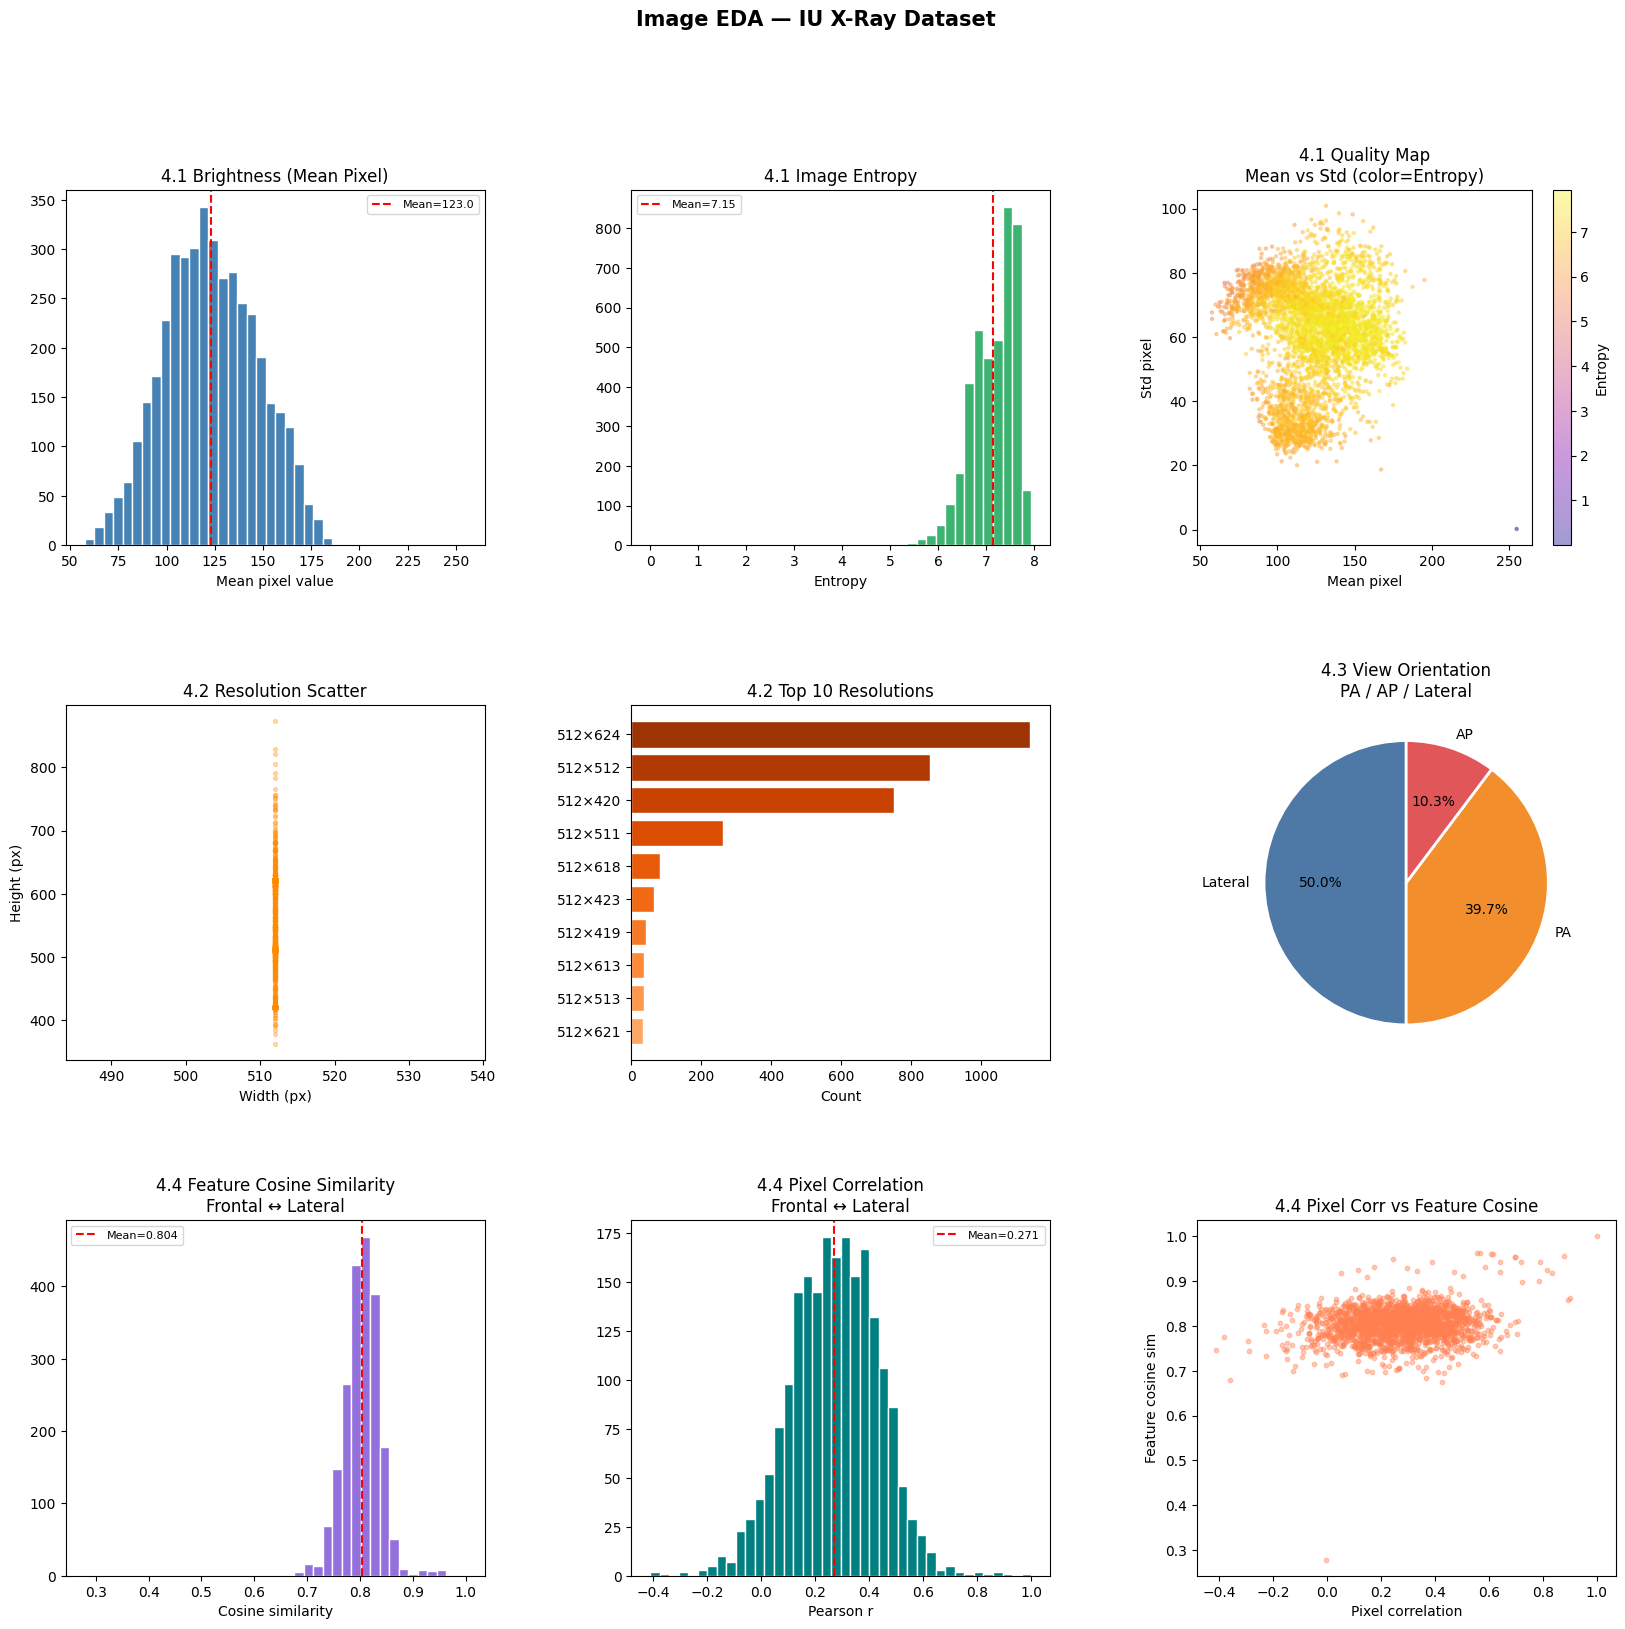

In [28]:
# ════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 18))
fig.suptitle("Image EDA — IU X-Ray Dataset", fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 4.1a: Histogram mean pixel
ax = fig.add_subplot(gs[0, 0])
ax.hist(quality_df['mean_px'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(quality_df['mean_px'].mean(), color='red', linestyle='--',
           label=f"Mean={quality_df['mean_px'].mean():.1f}")
ax.set_title("4.1 Brightness (Mean Pixel)"); ax.set_xlabel("Mean pixel value")
ax.legend(fontsize=8)

# 4.1b: Entropy distribution
ax = fig.add_subplot(gs[0, 1])
ax.hist(quality_df['entropy'], bins=40, color='mediumseagreen', edgecolor='white')
ax.axvline(quality_df['entropy'].mean(), color='red', linestyle='--',
           label=f"Mean={quality_df['entropy'].mean():.2f}")
ax.set_title("4.1 Image Entropy"); ax.set_xlabel("Entropy")
ax.legend(fontsize=8)

# 4.1c: Quality map (mean vs std, color = entropy)
ax = fig.add_subplot(gs[0, 2])
sc = ax.scatter(quality_df['mean_px'], quality_df['std_px'],
                c=quality_df['entropy'], cmap='plasma', s=5, alpha=0.4)
plt.colorbar(sc, ax=ax, label='Entropy')
ax.set_title("4.1 Quality Map\nMean vs Std (color=Entropy)")
ax.set_xlabel("Mean pixel"); ax.set_ylabel("Std pixel")

# 4.2a: Resolution scatter
ax = fig.add_subplot(gs[1, 0])
ax.scatter(res_df['width'], res_df['height'], alpha=0.3, s=8, color='darkorange')
ax.set_title("4.2 Resolution Scatter"); ax.set_xlabel("Width (px)"); ax.set_ylabel("Height (px)")

# 4.2b: Top resolutions bar
ax = fig.add_subplot(gs[1, 1])
top_res = res_df['resolution'].value_counts().head(10)
ax.barh(top_res.index[::-1], top_res.values[::-1],
        color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_res))), edgecolor='white')
ax.set_title("4.2 Top 10 Resolutions"); ax.set_xlabel("Count")

# 4.3: Orientation pie
ax = fig.add_subplot(gs[1, 2])
orient_counts = orient_df['orientation'].value_counts()
ax.pie(orient_counts.values, labels=orient_counts.index,
       autopct='%1.1f%%', startangle=90,
       colors=['#4e79a7', '#f28e2b', '#e15759'],
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title("4.3 View Orientation\nPA / AP / Lateral")

# 4.4a: Cosine similarity histogram
ax = fig.add_subplot(gs[2, 0])
cos_vals = relation_df['feature_cos'].dropna()
ax.hist(cos_vals, bins=40, color='mediumpurple', edgecolor='white')
ax.axvline(cos_vals.mean(), color='red', linestyle='--',
           label=f"Mean={cos_vals.mean():.3f}")
ax.set_title("4.4 Feature Cosine Similarity\nFrontal ↔ Lateral")
ax.set_xlabel("Cosine similarity"); ax.legend(fontsize=8)

# 4.4b: Pixel correlation histogram
ax = fig.add_subplot(gs[2, 1])
ax.hist(relation_df['pixel_corr'], bins=40, color='teal', edgecolor='white')
ax.axvline(relation_df['pixel_corr'].mean(), color='red', linestyle='--',
           label=f"Mean={relation_df['pixel_corr'].mean():.3f}")
ax.set_title("4.4 Pixel Correlation\nFrontal ↔ Lateral")
ax.set_xlabel("Pearson r"); ax.legend(fontsize=8)

# 4.4c: Scatter pixel_corr vs feature_cos
ax = fig.add_subplot(gs[2, 2])
ax.scatter(relation_df['pixel_corr'], relation_df['feature_cos'],
           alpha=0.4, s=10, color='coral')
ax.set_title("4.4 Pixel Corr vs Feature Cosine")
ax.set_xlabel("Pixel correlation"); ax.set_ylabel("Feature cosine sim")

plt.tight_layout()
plt.show()

# 5. Image-Text Alignment Analysis

## 5.1 Clip Similarity

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

# ════════════════════════════════════════════════════════════════════
# 5.1  CLIP SIMILARITY — Image-Text Alignment
# ════════════════════════════════════════════════════════════════════
print("="*60)
print("  5.1  CLIP IMAGE-TEXT ALIGNMENT")
print("="*60)

try:
    import clip
    print("  ✓ clip package found")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "git+https://github.com/openai/CLIP.git", "-q"])
    import clip

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"  Device: {DEVICE}")

# Load CLIP model
print("  Loading CLIP ViT-B/32...")
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()

# ── Encode từng cặp (image, report) ──────────────────────────────────
alignment_records = []
SAMPLE_SIZE = min(500, len(train_df))   # giới hạn để chạy nhanh; bỏ min() để chạy full

sample_df = train_df.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

print(f"  Computing CLIP similarity for {SAMPLE_SIZE} samples...")

for _, row in tqdm(sample_df.iterrows(), total=SAMPLE_SIZE):
    findings = row['findings']
    if not isinstance(findings, list):
        findings = [findings]

    # Chỉ dùng ảnh đầu (frontal view)
    img_path = os.path.join(IMAGE_DIR, findings[0])
    if not os.path.exists(img_path):
        continue

    try:
        # Image embedding
        img_pil    = Image.open(img_path).convert('RGB')
        img_tensor = clip_preprocess(img_pil).unsqueeze(0).to(DEVICE)

        # Text embedding — CLIP tokenizer max 77 tokens
        report_trunc = row['report'][:200]   # truncate để an toàn
        text_tokens  = clip.tokenize([report_trunc], truncate=True).to(DEVICE)

        with torch.no_grad():
            img_feat  = clip_model.encode_image(img_tensor).float()
            text_feat = clip_model.encode_text(text_tokens).float()

            # Normalize
            img_feat  = F.normalize(img_feat,  dim=-1)
            text_feat = F.normalize(text_feat, dim=-1)

            similarity = float((img_feat * text_feat).sum(dim=-1).cpu())

        alignment_records.append({
            'image_id'    : row['image_id'],
            'img_path'    : img_path,
            'report'      : row['report'],
            'clip_sim'    : similarity,
            'report_len'  : len(row['report'].split()),
        })

    except Exception as e:
        continue

align_df = pd.DataFrame(alignment_records)

# ── Thống kê ─────────────────────────────────────────────────────────
print(f"\n  CLIP SIMILARITY SUMMARY  (n={len(align_df)})")
print("-"*45)
print(align_df['clip_sim'].describe().round(4).to_string())
print("-"*45)

# Phân loại alignment quality
align_df['alignment_quality'] = pd.cut(
    align_df['clip_sim'],
    bins   = [-1, 0.15, 0.20, 0.25, 1.0],
    labels = ['Poor (<0.15)', 'Weak (0.15–0.20)', 'Good (0.20–0.25)', 'Strong (>0.25)']
)

print(f"\n  ALIGNMENT QUALITY DISTRIBUTION")
print("-"*45)
for cat, cnt in align_df['alignment_quality'].value_counts().sort_index().items():
    pct = cnt / len(align_df) * 100
    bar = '█' * int(pct / 2)
    print(f"  {str(cat):<22} {cnt:>5} ({pct:.1f}%)  {bar}")
print("-"*45)

# Top best & worst aligned
print(f"\n  TOP 5 BEST ALIGNED")
print("-"*60)
for _, r in align_df.nlargest(5, 'clip_sim').iterrows():
    print(f"  [{r['clip_sim']:.4f}] {r['report']}...")

print(f"\n  TOP 5 WORST ALIGNED")
print("-"*60)
for _, r in align_df.nsmallest(5, 'clip_sim').iterrows():
    print(f"  [{r['clip_sim']:.4f}] {r['report']}...")


  5.1  CLIP IMAGE-TEXT ALIGNMENT
  ✓ clip package found
  Device: cuda
  Loading CLIP ViT-B/32...
  Computing CLIP similarity for 500 samples...


100%|██████████| 500/500 [00:24<00:00, 20.36it/s]


  CLIP SIMILARITY SUMMARY  (n=500)
---------------------------------------------
count    500.0000
mean       0.3003
std        0.0145
min        0.2547
25%        0.2913
50%        0.3017
75%        0.3107
max        0.3375
---------------------------------------------

  ALIGNMENT QUALITY DISTRIBUTION
---------------------------------------------
  Poor (<0.15)               0 (0.0%)  
  Weak (0.15–0.20)           0 (0.0%)  
  Good (0.20–0.25)           0 (0.0%)  
  Strong (>0.25)           500 (100.0%)  ██████████████████████████████████████████████████
---------------------------------------------

  TOP 5 BEST ALIGNED
------------------------------------------------------------
  [0.3375] Lungs are hyperinflated with flattening of the diaphragms and increased AP chest diameter, compatible with emphysema. There is no evidence of focal infiltrate, pneumothorax, pleural effusion, or identified mass lesion. There is normal cardiomediastinal contours....
  [0.3373] The XXXX examinatio

## 5.2 Patch-to-word alignment

In [31]:
# ════════════════════════════════════════════════════════════════════
# 5.2  PATCH-TO-WORD ALIGNMENT — GradCAM + CLIP Attention
# ════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  5.2  PATCH-TO-WORD ALIGNMENT (GradCAM + CLIP Attention)")
print("="*60)

import torchvision.models as tvm
import torchvision.transforms as T

# ── GradCAM implementation ────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward()

        # Pooling gradients
        pooled_grads = self.gradients.mean(dim=[0, 2, 3])
        cam = self.activations.squeeze(0)

        for i, w in enumerate(pooled_grads):
            cam[i] *= w

        cam = cam.mean(dim=0).relu()
        cam = cam.numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam


def apply_gradcam_overlay(img_path: str, cam: np.ndarray) -> np.ndarray:
    """Overlay GradCAM heatmap lên ảnh gốc"""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    heatmap = cv2.resize(cam, (w, h))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = (0.5 * img + 0.5 * heatmap).astype(np.uint8)
    return img, heatmap, overlay


# Load ResNet với GradCAM
resnet_gc = tvm.resnet50(weights='DEFAULT')
resnet_gc.eval()
target_layer = resnet_gc.layer4[-1].conv3   # layer cuối trước avgpool

gradcam = GradCAM(resnet_gc, target_layer)

preprocess_gc = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── CLIP Attention Map ────────────────────────────────────────────────
def get_clip_attention(img_path: str, text: str) -> np.ndarray | None:
    """
    Trích xuất attention map từ CLIP ViT last layer.
    Patch tokens attend to [CLS] token → reshape thành spatial map.
    """
    try:
        img_pil    = Image.open(img_path).convert('RGB')
        img_tensor = clip_preprocess(img_pil).unsqueeze(0).to(DEVICE)

        attn_maps = []

        def attn_hook(module, input, output):
            # output shape: (batch, heads, seq_len, seq_len)
            attn_maps.append(output[1].detach().cpu() if isinstance(output, tuple)
                             else output.detach().cpu())

        # Hook vào last transformer block của ViT
        hook = clip_model.visual.transformer.resblocks[-1].attn.register_forward_hook(attn_hook)

        with torch.no_grad():
            _ = clip_model.encode_image(img_tensor)
        hook.remove()

        if not attn_maps:
            return None

        # [CLS] token là index 0; lấy attention từ tất cả patches về CLS
        attn = attn_maps[0]  # (1, heads, seq_len, seq_len)
        if attn is None:
            return None

        attn_cls = attn[0, :, 0, 1:]  # (heads, n_patches)
        attn_cls = attn_cls.mean(0)    # average over heads → (n_patches,)
        n        = int(attn_cls.shape[0] ** 0.5)
        attn_map = attn_cls.reshape(n, n).numpy()
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)
        return attn_map

    except Exception as e:
        return None


# ── Chọn 4 ví dụ đại diện để visualize ──────────────────────────────
# Best aligned, worst aligned, average (2 mẫu)
best2  = align_df.nlargest(2,  'clip_sim')
worst2 = align_df.nsmallest(2, 'clip_sim')
viz_samples = pd.concat([best2, worst2]).reset_index(drop=True)
viz_labels  = ['Best #1', 'Best #2', 'Worst #1', 'Worst #2']




  5.2  PATCH-TO-WORD ALIGNMENT (GradCAM + CLIP Attention)
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 137MB/s]


## 5.3 VISUALIZATION

/tmp/ipykernel_518/1554861631.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


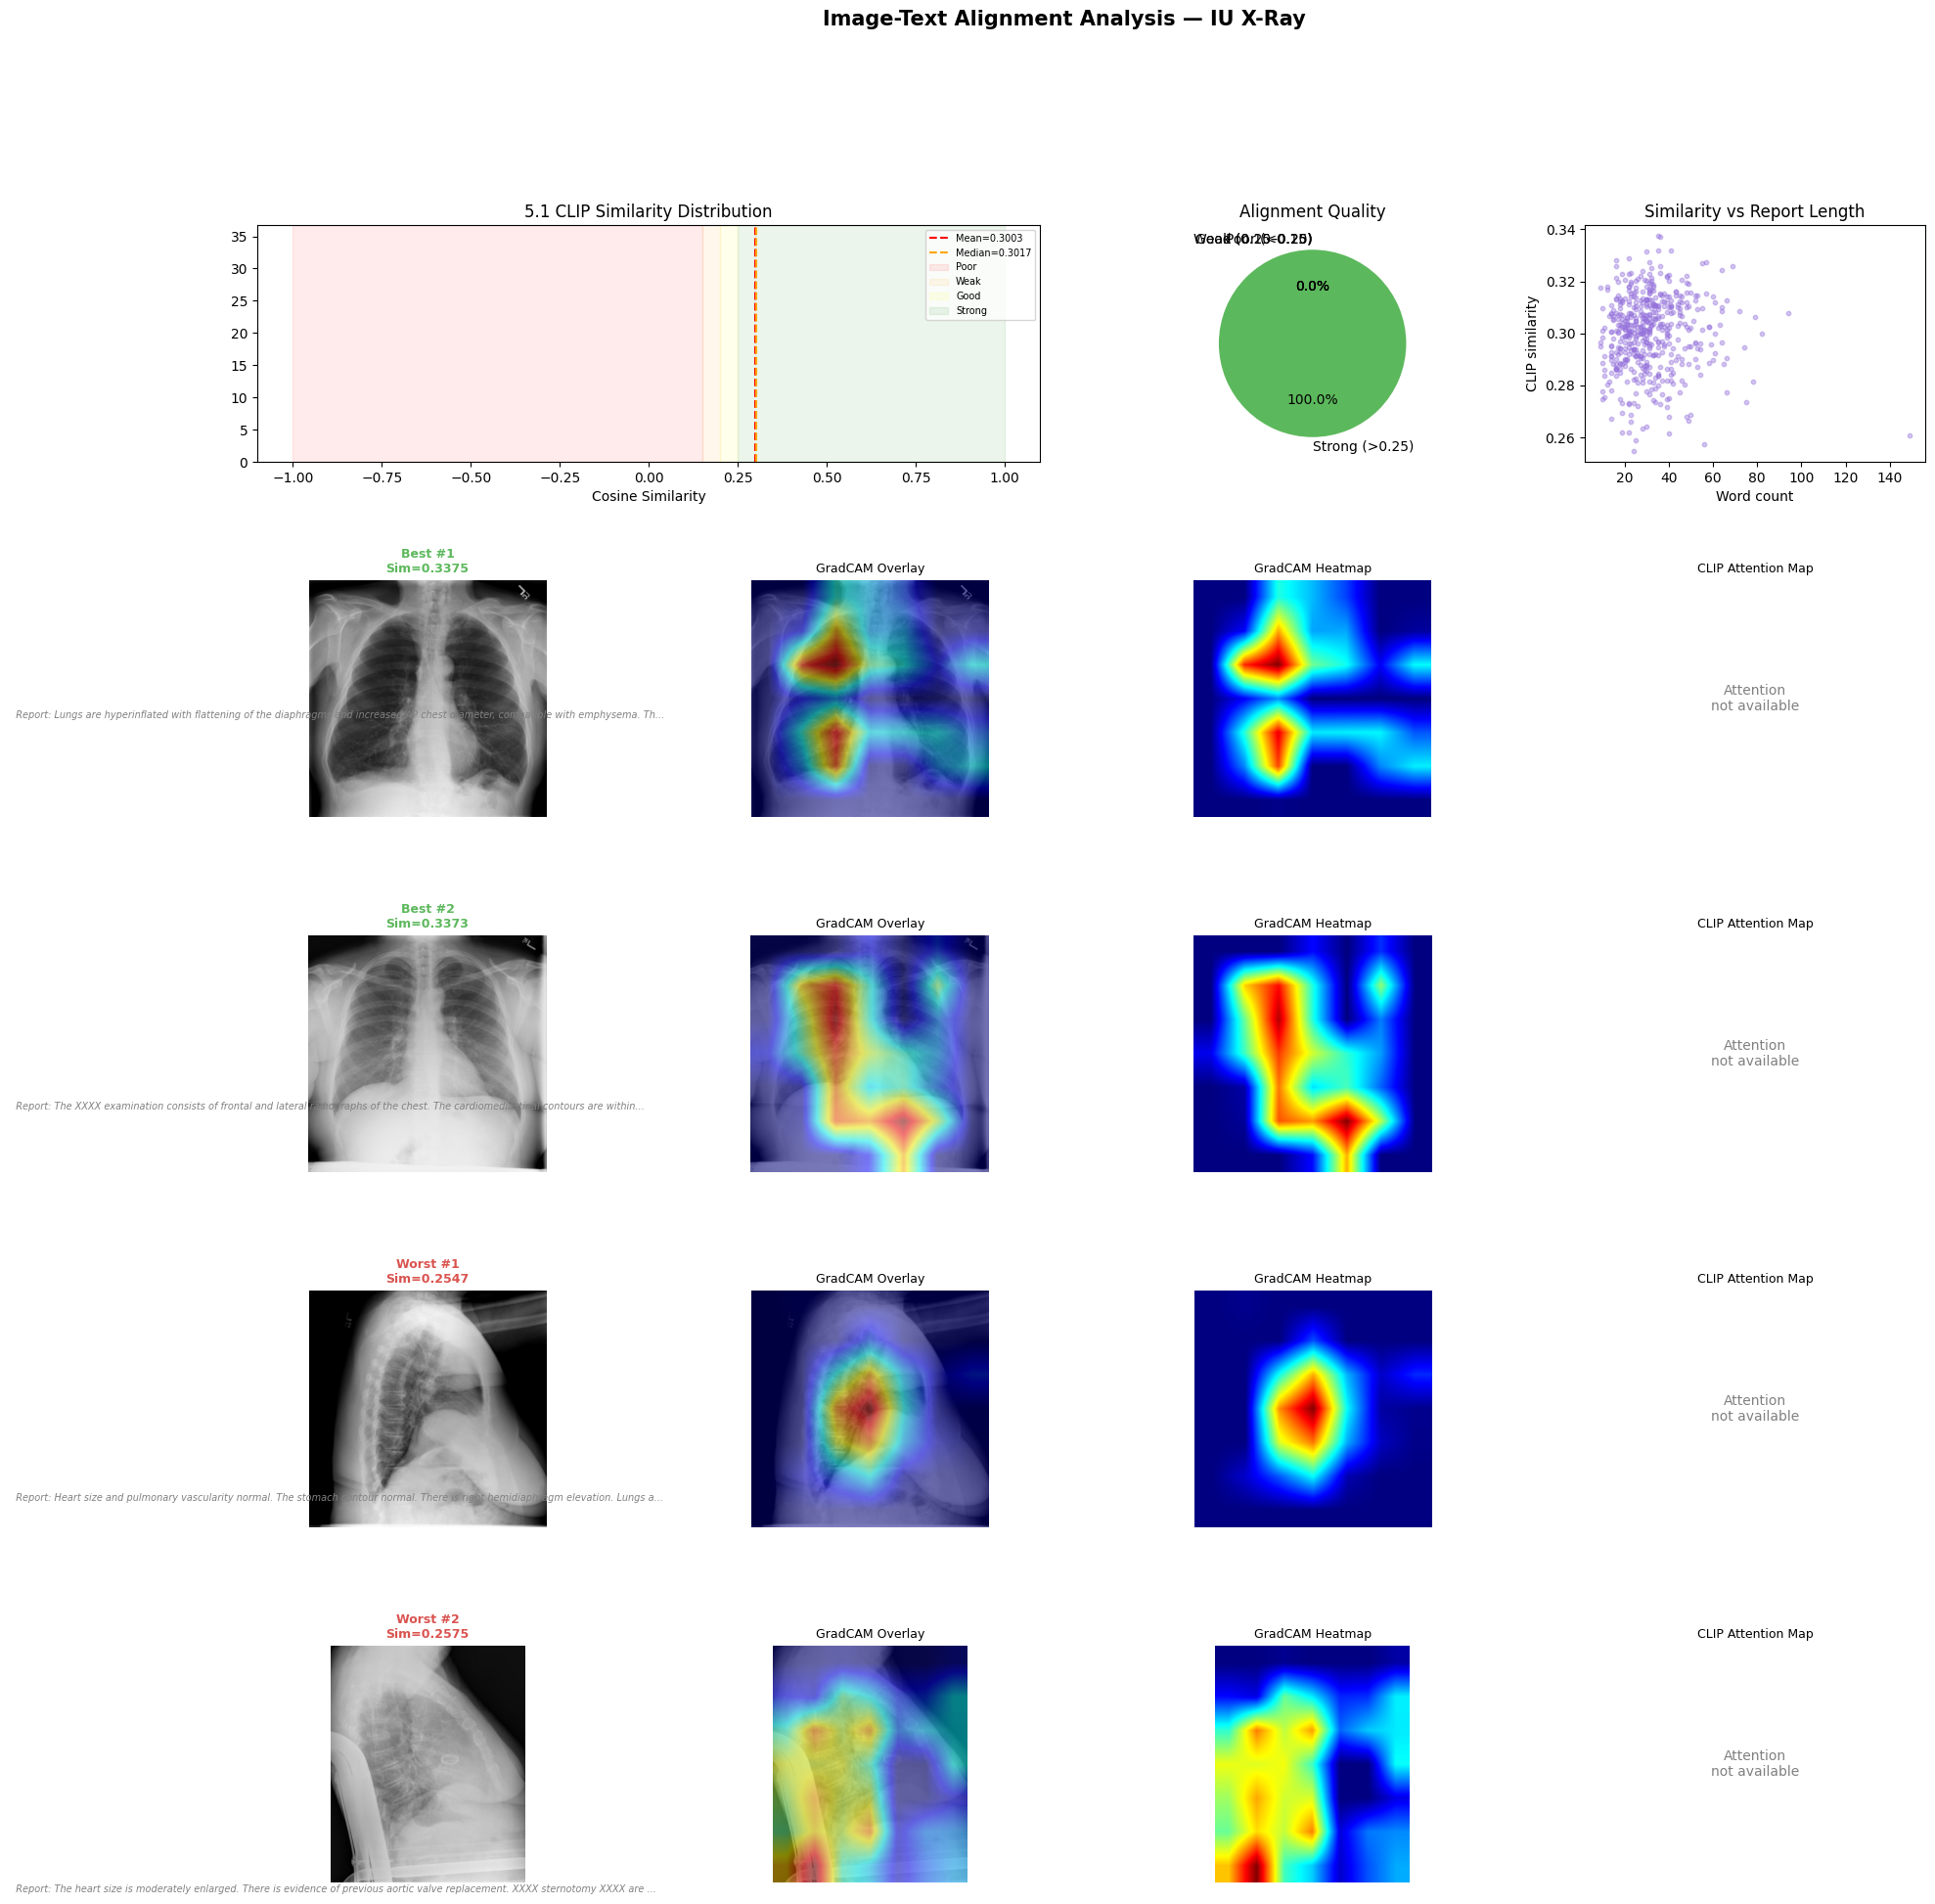

In [32]:
# ════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(22, 22))
fig.suptitle("Image-Text Alignment Analysis — IU X-Ray", fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(5, 4, figure=fig, hspace=0.5, wspace=0.3)

# ── Row 0: CLIP similarity distribution ──────────────────────────────
ax = fig.add_subplot(gs[0, :2])
ax.hist(align_df['clip_sim'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(align_df['clip_sim'].mean(), color='red', linestyle='--',
           label=f"Mean={align_df['clip_sim'].mean():.4f}")
ax.axvline(align_df['clip_sim'].median(), color='orange', linestyle='--',
           label=f"Median={align_df['clip_sim'].median():.4f}")
ax.axvspan(-1, 0.15, alpha=0.08, color='red',   label='Poor')
ax.axvspan(0.15, 0.20, alpha=0.08, color='orange', label='Weak')
ax.axvspan(0.20, 0.25, alpha=0.08, color='yellow', label='Good')
ax.axvspan(0.25, 1.0,  alpha=0.08, color='green',  label='Strong')
ax.set_title("5.1 CLIP Similarity Distribution"); ax.set_xlabel("Cosine Similarity")
ax.legend(fontsize=7)

# ── Row 0: Alignment quality pie ─────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
q_counts = align_df['alignment_quality'].value_counts().sort_index()
ax.pie(q_counts.values, labels=q_counts.index, autopct='%1.1f%%',
       colors=['#d9534f','#f0ad4e','#f7ec59','#5cb85c'],
       startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax.set_title("Alignment Quality")

# ── Row 0: Scatter similarity vs report length ────────────────────────
ax = fig.add_subplot(gs[0, 3])
ax.scatter(align_df['report_len'], align_df['clip_sim'],
           alpha=0.4, s=10, color='mediumpurple')
ax.set_title("Similarity vs Report Length")
ax.set_xlabel("Word count"); ax.set_ylabel("CLIP similarity")

# ── Rows 1–4: GradCAM + CLIP Attention cho 4 mẫu ─────────────────────
for idx, (_, sample) in enumerate(viz_samples.iterrows()):
    row_offset = idx + 1
    img_path   = sample['img_path']
    label      = viz_labels[idx]
    sim        = sample['clip_sim']
    report     = sample['report'][:120] + '...'

    # GradCAM
    try:
        img_pil_gc = Image.open(img_path).convert('L')
        tensor_gc  = preprocess_gc(img_pil_gc).unsqueeze(0)
        cam        = gradcam.generate(tensor_gc)
        orig, heatmap, overlay = apply_gradcam_overlay(img_path, cam)
    except Exception:
        orig = heatmap = overlay = np.zeros((224, 224, 3), dtype=np.uint8)
        cam  = np.zeros((7, 7))

    # CLIP Attention
    attn_map = get_clip_attention(img_path, report)

    # Col 0: Original image
    ax = fig.add_subplot(gs[row_offset, 0])
    ax.imshow(orig, cmap='gray' if orig.ndim == 2 else None)
    color = '#5cb85c' if 'Best' in label else '#d9534f'
    ax.set_title(f"{label}\nSim={sim:.4f}", fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

    # Col 1: GradCAM overlay
    ax = fig.add_subplot(gs[row_offset, 1])
    ax.imshow(overlay)
    ax.set_title("GradCAM Overlay", fontsize=9)
    ax.axis('off')

    # Col 2: GradCAM heatmap only
    ax = fig.add_subplot(gs[row_offset, 2])
    ax.imshow(heatmap)
    ax.set_title("GradCAM Heatmap", fontsize=9)
    ax.axis('off')

    # Col 3: CLIP Attention map
    ax = fig.add_subplot(gs[row_offset, 3])
    if attn_map is not None:
        ax.imshow(attn_map, cmap='hot', interpolation='bilinear')
        ax.set_title("CLIP Attention Map", fontsize=9)
    else:
        ax.text(0.5, 0.5, 'Attention\nnot available',
                ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.set_title("CLIP Attention Map", fontsize=9)
    ax.axis('off')

    # Report text bên dưới
    fig.text(0.01, 1 - (row_offset + 0.92) / 5.5,
             f"  Report: {report}", fontsize=7, color='gray',
             ha='left', style='italic')

plt.tight_layout()
plt.show()

Computing text t-SNE...
Extracting CNN features for image t-SNE...


CNN features: 100%|██████████| 600/600 [00:08<00:00, 67.50it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Computing image t-SNE...


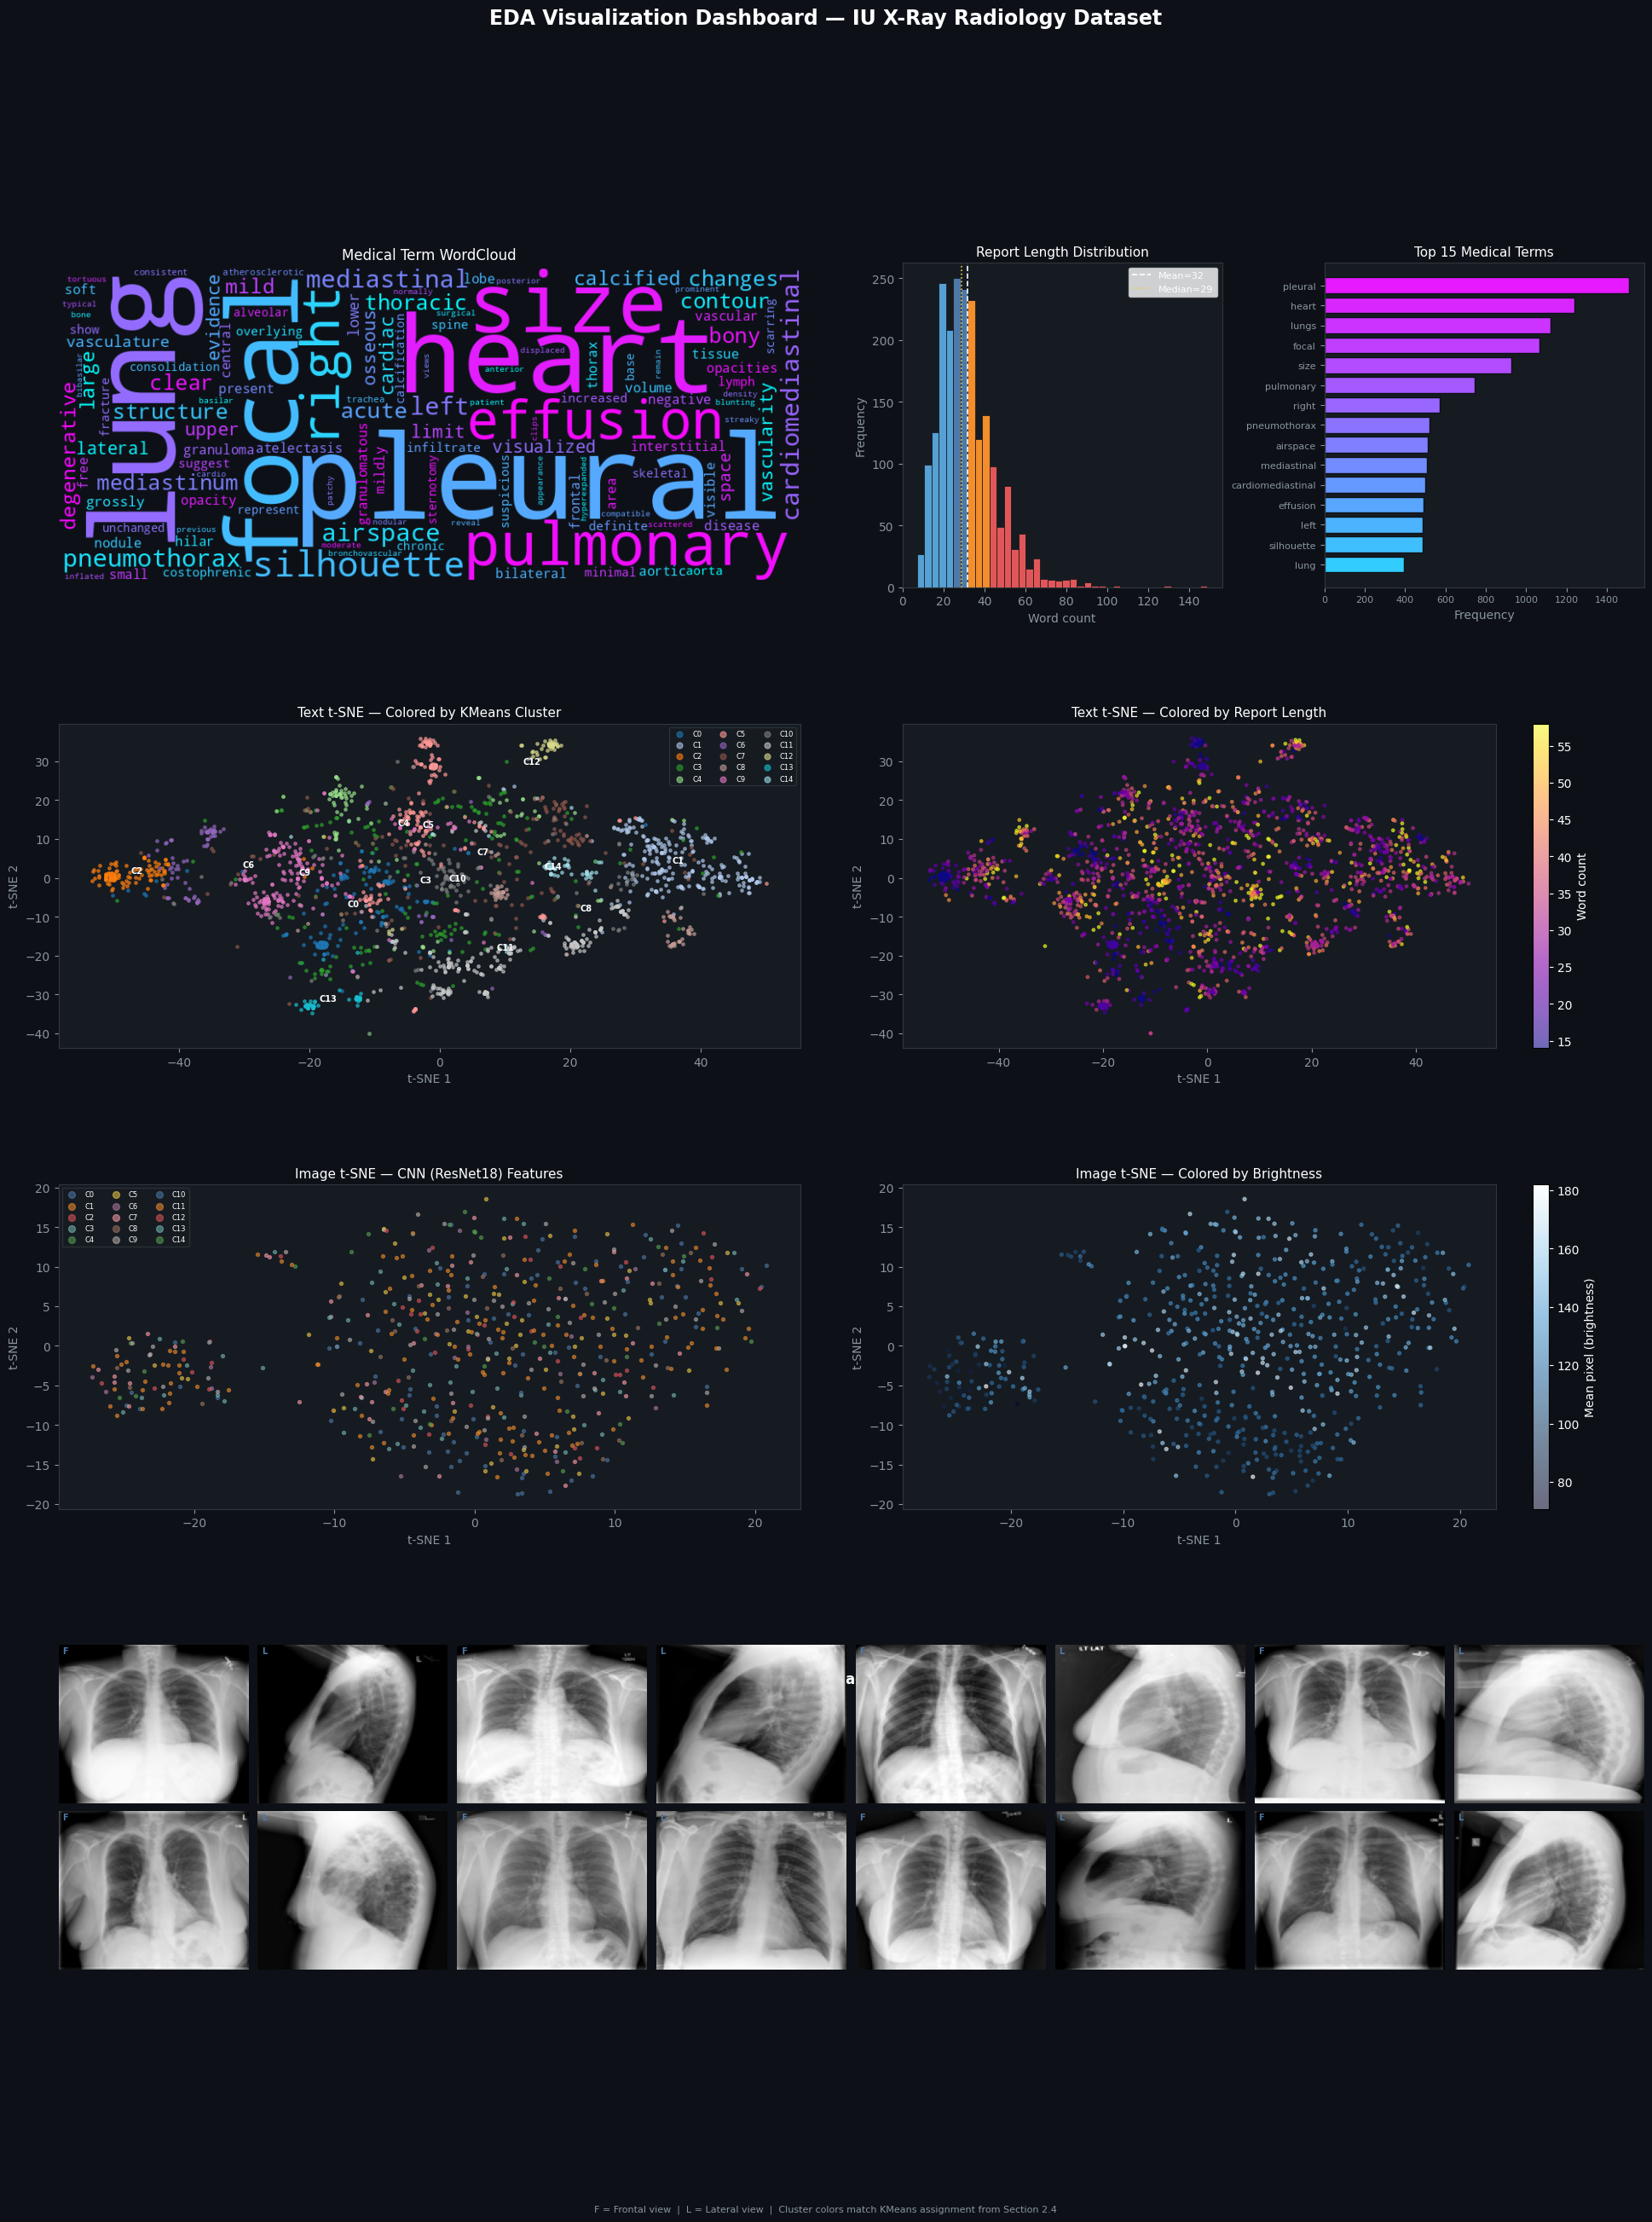

  ✓ Saved: eda_visualization_dashboard.png


In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from wordcloud import WordCloud, STOPWORDS
from sklearn.manifold import TSNE
from PIL import Image
import torchvision.transforms as T
import torchvision.models as models

# ════════════════════════════════════════════════════════════════════
# SETUP
# ════════════════════════════════════════════════════════════════════
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
PALETTE  = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f',
            '#edc948','#b07aa1','#ff9da7','#9c755f','#bab0ac']

# Medical stopwords để wordcloud sạch hơn
MEDICAL_STOPWORDS = set(STOPWORDS) | {
    'the','and','is','are','was','were','with','has','have','been',
    'there','no','of','in','to','a','an','at','on','for','as','or',
    'that','this','which','also','than','but','not','may','well',
    'would','could','appear','appears','noted','note','seen','see',
    'impression','findings','finding','without','within','normal',
    'otherwise','interval', 'change', 'stable', 'since', 'prior',
    'examination', 'radiograph', 'study', 'view', 'chest', 'xxxx'
}

# Custom colormap X-ray style
xray_cmap = LinearSegmentedColormap.from_list(
    'xray', ['#0a0a2e','#1a3a5c','#2e6b9e','#56a0d3','#a8d4f0','#ffffff']
)

# ════════════════════════════════════════════════════════════════════
# TEXT VISUALIZATIONS
# ════════════════════════════════════════════════════════════════════

# ── T1: Corpus cho WordCloud ──────────────────────────────────────────
all_text      = ' '.join(train_df['report'].str.lower())
medical_terms = ' '.join([
    w for w in all_text.split()
    if w not in MEDICAL_STOPWORDS and len(w) > 3 and w.isalpha()
])

# ── T2: Word frequency top 30 ────────────────────────────────────────
from collections import Counter
word_freq = Counter([
    w for w in all_text.split()
    if w not in MEDICAL_STOPWORDS and len(w) > 3 and w.isalpha()
])
top30      = pd.DataFrame(word_freq.most_common(30), columns=['word','count'])
top30['pct'] = (top30['count'] / len(train_df) * 100).round(1)

# ── T3: Report length ─────────────────────────────────────────────────
if 'report_word_count' not in train_df.columns:
    train_df['report_word_count'] = train_df['report'].apply(lambda x: len(x.split()))
word_counts = train_df['report_word_count']

# ── T4: t-SNE on sentence embeddings (text clusters) ─────────────────
print("Computing text t-SNE...")
tsne_text = TSNE(
    n_components=2, perplexity=40, max_iter=1000,
    random_state=42, metric='cosine', init='pca'
)
coords_text = tsne_text.fit_transform(embeddings_all)

# ════════════════════════════════════════════════════════════════════
# IMAGE VISUALIZATIONS — CNN feature extraction + t-SNE
# ════════════════════════════════════════════════════════════════════
print("Extracting CNN features for image t-SNE...")

resnet_viz    = models.resnet18(weights='DEFAULT')
resnet_viz.fc = torch.nn.Identity()
resnet_viz.eval().to(DEVICE)

preprocess_viz = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# Lấy frontal view của mỗi report
IMG_SAMPLE  = min(600, len(train_df))
sample_rows = train_df.sample(IMG_SAMPLE, random_state=42).reset_index(drop=True)

img_features, img_paths_viz, img_labels = [], [], []

for _, row in tqdm(sample_rows.iterrows(), total=IMG_SAMPLE, desc="CNN features"):
    findings = row['findings']
    if not isinstance(findings, list):
        findings = [findings]
    fp = os.path.join(IMAGE_DIR, findings[0])
    if not os.path.exists(fp):
        continue
    try:
        pil  = Image.open(fp).convert('L')
        tens = preprocess_viz(pil).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            feat = resnet_viz(tens).squeeze().cpu().numpy()
        img_features.append(feat)
        img_paths_viz.append(fp)
        img_labels.append(row.get('cluster', 0))
    except Exception:
        continue

img_features = np.array(img_features)

print("Computing image t-SNE...")
tsne_img    = TSNE(n_components=2, perplexity=35, n_iter=1000,
                   random_state=42, init='pca')
coords_img  = tsne_img.fit_transform(img_features)

# Brightness per image (dùng quality_df nếu có)
if 'quality_df' in dir() or 'quality_df' in globals():
    brightness_vals = quality_df.set_index('rel_path')['mean_px'].to_dict()
    img_brightness  = [brightness_vals.get(
        os.path.relpath(p, IMAGE_DIR).replace('\\','/'), 128.0
    ) for p in img_paths_viz]
else:
    img_brightness = []
    for fp in img_paths_viz:
        try:
            img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
            img_brightness.append(float(img.mean()) if img is not None else 128.0)
        except Exception:
            img_brightness.append(128.0)
img_brightness = np.array(img_brightness)

# Sample images for visualization grid
N_SAMPLE_VIZ = 16
sample_img_rows = train_df.sample(N_SAMPLE_VIZ, random_state=7).reset_index(drop=True)

# ════════════════════════════════════════════════════════════════════
# FULL VISUALIZATION FIGURE  (4 rows × 4 cols)
# ════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(24, 26))
fig.patch.set_facecolor('#0d1117')
fig.suptitle("EDA Visualization Dashboard — IU X-Ray Radiology Dataset",
             fontsize=17, fontweight='bold', color='white', y=0.995)

gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.42, wspace=0.32)

# ─────────────────────────────────────────────────────────────────────
# ROW 0 — TEXT
# ─────────────────────────────────────────────────────────────────────

# [0,0:2] WordCloud
ax_wc = fig.add_subplot(gs[0, :2])
wc = WordCloud(
    width=900, height=380,
    background_color='#0d1117',
    colormap='cool',
    stopwords=MEDICAL_STOPWORDS,
    max_words=120,
    prefer_horizontal=0.85,
    min_font_size=9,
    collocations=False,
).generate(medical_terms)
ax_wc.imshow(wc, interpolation='bilinear')
ax_wc.set_title("Medical Term WordCloud", color='white', fontsize=12, pad=8)
ax_wc.axis('off')
ax_wc.set_facecolor('#0d1117')

# [0,2] Report length histogram
ax_rl = fig.add_subplot(gs[0, 2])
ax_rl.set_facecolor('#161b22')
n, bins, patches = ax_rl.hist(word_counts, bins=40,
                               color='#4e79a7', edgecolor='#0d1117', linewidth=0.5)
# Color by quartile
q1, q2, q3 = word_counts.quantile([0.25, 0.5, 0.75])
for patch, left in zip(patches, bins[:-1]):
    if left < q1:    patch.set_facecolor('#56a0d3')
    elif left < q2:  patch.set_facecolor('#4e79a7')
    elif left < q3:  patch.set_facecolor('#f28e2b')
    else:            patch.set_facecolor('#e15759')

ax_rl.axvline(word_counts.mean(),   color='#ffffff', linestyle='--', lw=1.2,
              label=f"Mean={word_counts.mean():.0f}")
ax_rl.axvline(word_counts.median(), color='#edc948', linestyle=':',  lw=1.2,
              label=f"Median={word_counts.median():.0f}")
ax_rl.set_title("Report Length Distribution", color='white', fontsize=11)
ax_rl.set_xlabel("Word count", color='#8b949e'); ax_rl.set_ylabel("Frequency", color='#8b949e')
ax_rl.tick_params(colors='#8b949e'); ax_rl.legend(fontsize=8, labelcolor='white')
for spine in ax_rl.spines.values(): spine.set_edgecolor('#30363d')

# [0,3] Top 15 medical terms bar
ax_tf = fig.add_subplot(gs[0, 3])
ax_tf.set_facecolor('#161b22')
top15 = top30.head(15)
colors_bar = plt.cm.cool(np.linspace(0.2, 0.9, len(top15)))
bars = ax_tf.barh(top15['word'][::-1], top15['count'][::-1],
                  color=colors_bar, edgecolor='#0d1117')
ax_tf.set_title("Top 15 Medical Terms", color='white', fontsize=11)
ax_tf.set_xlabel("Frequency", color='#8b949e')
ax_tf.tick_params(colors='#8b949e', labelsize=8)
for spine in ax_tf.spines.values(): spine.set_edgecolor('#30363d')

# ─────────────────────────────────────────────────────────────────────
# ROW 1 — TEXT t-SNE + cluster
# ─────────────────────────────────────────────────────────────────────

# [1, :2] t-SNE colored by cluster
ax_ts = fig.add_subplot(gs[1, :2])
ax_ts.set_facecolor('#161b22')
cluster_colors = plt.cm.tab20(np.linspace(0, 1, OPTIMAL_K))

for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    ax_ts.scatter(coords_text[mask, 0], coords_text[mask, 1],
                  color=cluster_colors[c], s=6, alpha=0.6, label=f'C{c}')
    cx = coords_text[mask, 0].mean() if mask.any() else 0
    cy = coords_text[mask, 1].mean() if mask.any() else 0
    ax_ts.annotate(f'C{c}', (cx, cy), color='white', fontsize=7,
                   fontweight='bold', ha='center')

ax_ts.set_title("Text t-SNE — Colored by KMeans Cluster",
                color='white', fontsize=11)
ax_ts.set_xlabel("t-SNE 1", color='#8b949e'); ax_ts.set_ylabel("t-SNE 2", color='#8b949e')
ax_ts.tick_params(colors='#8b949e')
ax_ts.legend(fontsize=6, ncol=3, labelcolor='white',
             facecolor='#161b22', edgecolor='#30363d', markerscale=2)
for spine in ax_ts.spines.values(): spine.set_edgecolor('#30363d')

# [1, 2:] t-SNE colored by word count
ax_tw = fig.add_subplot(gs[1, 2:])
ax_tw.set_facecolor('#161b22')
sc_w = ax_tw.scatter(coords_text[:, 0], coords_text[:, 1],
                     c=word_counts.values, cmap='plasma', s=6, alpha=0.6,
                     vmin=word_counts.quantile(0.05),
                     vmax=word_counts.quantile(0.95))
cbar = plt.colorbar(sc_w, ax=ax_tw)
cbar.set_label('Word count', color='white'); cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
ax_tw.set_title("Text t-SNE — Colored by Report Length",
                color='white', fontsize=11)
ax_tw.set_xlabel("t-SNE 1", color='#8b949e'); ax_tw.set_ylabel("t-SNE 2", color='#8b949e')
ax_tw.tick_params(colors='#8b949e')
for spine in ax_tw.spines.values(): spine.set_edgecolor('#30363d')

# ─────────────────────────────────────────────────────────────────────
# ROW 2 — IMAGE t-SNE + brightness
# ─────────────────────────────────────────────────────────────────────

# [2, :2] Image t-SNE colored by cluster
ax_it = fig.add_subplot(gs[2, :2])
ax_it.set_facecolor('#161b22')
img_label_arr = np.array(img_labels)
unique_lbls   = np.unique(img_label_arr)
for lbl in unique_lbls:
    mask = img_label_arr == lbl
    c    = PALETTE[int(lbl) % len(PALETTE)]
    ax_it.scatter(coords_img[mask, 0], coords_img[mask, 1],
                  color=c, s=8, alpha=0.55, label=f'C{lbl}')

ax_it.set_title("Image t-SNE — CNN (ResNet18) Features",
                color='white', fontsize=11)
ax_it.set_xlabel("t-SNE 1", color='#8b949e'); ax_it.set_ylabel("t-SNE 2", color='#8b949e')
ax_it.tick_params(colors='#8b949e')
ax_it.legend(fontsize=6, ncol=3, labelcolor='white',
             facecolor='#161b22', edgecolor='#30363d', markerscale=2)
for spine in ax_it.spines.values(): spine.set_edgecolor('#30363d')

# [2, 2:] Image t-SNE colored by brightness
ax_ib = fig.add_subplot(gs[2, 2:])
ax_ib.set_facecolor('#161b22')
sc_b = ax_ib.scatter(coords_img[:, 0], coords_img[:, 1],
                     c=img_brightness, cmap=xray_cmap, s=8, alpha=0.6)
cbar2 = plt.colorbar(sc_b, ax=ax_ib)
cbar2.set_label('Mean pixel (brightness)', color='white')
cbar2.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white')
ax_ib.set_title("Image t-SNE — Colored by Brightness",
                color='white', fontsize=11)
ax_ib.set_xlabel("t-SNE 1", color='#8b949e'); ax_ib.set_ylabel("t-SNE 2", color='#8b949e')
ax_ib.tick_params(colors='#8b949e')
for spine in ax_ib.spines.values(): spine.set_edgecolor('#30363d')

# ─────────────────────────────────────────────────────────────────────
# ROW 3 — Sample image grid (4×4 = 16 ảnh)
# ─────────────────────────────────────────────────────────────────────
ax_title = fig.add_subplot(gs[3, :])
ax_title.axis('off')
ax_title.text(0.5, 0.92, "Sample X-Ray Images with Reports",
              ha='center', va='top', color='white',
              fontsize=12, fontweight='bold', transform=ax_title.transAxes)

# Vẽ 16 ảnh trong gs[3] bằng inset_axes
gs_inner = gridspec.GridSpecFromSubplotSpec(
    2, 8, subplot_spec=gs[3, :], hspace=0.05, wspace=0.05
)

viz_idx = 0
for r in range(2):
    for c_idx in range(8):
        ax_s = fig.add_subplot(gs_inner[r, c_idx])
        ax_s.set_facecolor('#0d1117')
        if viz_idx >= len(sample_img_rows):
            ax_s.axis('off')
            viz_idx += 1
            continue

        row_s    = sample_img_rows.iloc[viz_idx]
        findings = row_s['findings']
        if not isinstance(findings, list):
            findings = [findings]

        # Alternating: frontal (even) / lateral (odd)
        img_idx = 0 if c_idx % 2 == 0 else min(1, len(findings)-1)
        fp      = os.path.join(IMAGE_DIR, findings[img_idx])

        try:
            img_pil = Image.open(fp).convert('L').resize((128, 128))
            img_np  = np.array(img_pil)
            ax_s.imshow(img_np, cmap='gray', aspect='auto')
            view_label = 'F' if img_idx == 0 else 'L'
            ax_s.text(2, 6, view_label, color='#4e79a7',
                      fontsize=7, fontweight='bold')
        except Exception:
            ax_s.text(0.5, 0.5, 'N/A', ha='center', va='center',
                      color='gray', transform=ax_s.transAxes)

        ax_s.axis('off')
        viz_idx += 1

# Footnote
fig.text(0.5, 0.001,
         "F = Frontal view  |  L = Lateral view  |  "
         "Cluster colors match KMeans assignment from Section 2.4",
         ha='center', color='#8b949e', fontsize=8)

plt.savefig('eda_visualization_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("  ✓ Saved: eda_visualization_dashboard.png")